In [2]:
# ── Cell 1: Environment Check ──────────────────────────
import torch
print("PyTorch version :", torch.__version__)
print("GPU available   :", torch.cuda.is_available())
print("GPU name        :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# Install anything missing
import subprocess
subprocess.run(["pip", "install", "timm", "-q"])  # for pretrained models
print("\nAll packages ready.")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 84.8 MB/s eta 0:00:00

All packages ready.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [3]:
# ── Cell 1: Environment Check ──────────────────────────
import torch
print("PyTorch version :", torch.__version__)
print("GPU available   :", torch.cuda.is_available())
print("GPU name        :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

# Install anything missing
import subprocess
subprocess.run(["pip", "install", "timm", "-q"])  # for pretrained models
print("\nAll packages ready.")

PyTorch version : 2.10.0+cu128
GPU available   : True
GPU name        : Tesla T4

All packages ready.


In [4]:
# ── Cell 2: Project Structure ───────────────────────────
import os

BASE = "/kaggle/working/dermafusion"

folders = [
    "data",
    "models",
    "utils",
    "checkpoints",
    "outputs/plots",
    "outputs/results",
]

for f in folders:
    os.makedirs(f"{BASE}/{f}", exist_ok=True)
    # create empty __init__.py in module folders
    if f in ["data", "models", "utils"]:
        open(f"{BASE}/{f}/__init__.py", "w").close()

# Write config.py
config_code = '''
# DermaFusion — Central Config
# All hyperparameters in one place. Change here, affects everywhere.

import os

# ── Paths ──────────────────────────────────────────────
DATA_ROOT    = "/kaggle/input/pad-ufes-20"
IMG_DIR      = f"{DATA_ROOT}/images"
META_CSV     = f"{DATA_ROOT}/metadata.csv"
CHECKPOINT   = "/kaggle/working/dermafusion/checkpoints"
OUTPUT       = "/kaggle/working/dermafusion/outputs"

# ── Dataset ─────────────────────────────────────────────
CLASSES      = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
NUM_CLASSES  = 6
IMG_SIZE     = 224
RANDOM_SEED  = 42
TRAIN_SPLIT  = 0.70
VAL_SPLIT    = 0.15
TEST_SPLIT   = 0.15

# ── Clinical features (26 columns used) ────────────────
CLINICAL_FEATURES = [
    "age", "gender", "smoke", "drink", "pesticide",
    "skin_cancer_history", "cancer_history",
    "has_piped_water", "has_sewage_system",
    "fitspatrick", "region", "diameter_1", "diameter_2",
    "itch", "grew", "hurt", "changed", "bleed", "elevation",
    "biopsed"
]
NUM_CLINICAL = len(CLINICAL_FEATURES)  # 20 after dropping redundant cols

# ── Model ────────────────────────────────────────────────
IMAGE_FEATURE_DIM    = 512   # ResNet50 output after projection
CLINICAL_FEATURE_DIM = 256   # MLP encoder output
ATTN_HEADS           = 8     # MultiheadAttention heads
FUSED_DIM            = IMAGE_FEATURE_DIM + CLINICAL_FEATURE_DIM  # 768

# ── Training ─────────────────────────────────────────────
BATCH_SIZE     = 32
EPOCHS         = 100
LR_CNN         = 1e-5   # lower LR for pretrained ResNet50 layers
LR_MLP         = 1e-4   # higher LR for clinical MLP (trains from scratch)
LR_HEAD        = 1e-4   # classification head
WEIGHT_DECAY   = 1e-4
DROPOUT_MLP    = 0.3
DROPOUT_HEAD   = 0.4
PATIENCE       = 10     # early stopping patience
'''

with open(f"{BASE}/config.py", "w") as f:
    f.write(config_code)

# Print structure
for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

print("\nProject structure created successfully.")

dermafusion/
  config.py
  models/
    __init__.py
  checkpoints/
  data/
    __init__.py
  outputs/
    plots/
    results/
  utils/
    __init__.py

Project structure created successfully.


In [5]:
# Find exact dataset path
import os

print("Contents of /kaggle/input/:")
for item in os.listdir("/kaggle/input/"):
    print(f"  📁 {item}")
    subfolder = f"/kaggle/input/{item}"
    for sub in os.listdir(subfolder):
        print(f"      └── {sub}")

Contents of /kaggle/input/:
  📁 datasets
      └── mahdavi1202


In [6]:
import os

for item in os.listdir("/kaggle/input/"):
    print(f"📁 {item}")
    for sub in os.listdir(f"/kaggle/input/{item}"):
        print(f"    └── {sub}")

📁 datasets
    └── mahdavi1202


In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/mahdavi1202/"):
    print(root)
    for f in files[:3]:  # show first 3 files only
        print(f"    └── {f}")

/kaggle/input/datasets/mahdavi1202/
/kaggle/input/datasets/mahdavi1202/skin-cancer
    └── metadata.csv
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_1
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_1/imgs_part_1
    └── PAT_492_937_958.png
    └── PAT_13_21_350.png
    └── PAT_456_887_499.png
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_3
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_3/imgs_part_3
    └── PAT_1726_3228_674.png
    └── PAT_1913_3815_367.png
    └── PAT_1479_1669_376.png
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_2
/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_2/imgs_part_2
    └── PAT_650_3858_329.png
    └── PAT_766_1444_52.png
    └── PAT_806_1520_60.png


In [8]:
import pandas as pd
import os

# ── Correct paths ──────────────────────────────────────
BASE     = "/kaggle/input/datasets/mahdavi1202/skin-cancer"
META     = f"{BASE}/metadata.csv"
IMG_DIRS = [
    f"{BASE}/imgs_part_1/imgs_part_1",
    f"{BASE}/imgs_part_2/imgs_part_2",
    f"{BASE}/imgs_part_3/imgs_part_3",
]

# ── Update config.py with correct paths ────────────────
config_update = f'''
BASE     = "{BASE}"
META_CSV = "{META}"
IMG_DIRS = {IMG_DIRS}
'''
with open("/kaggle/working/dermafusion/config.py", "a") as f:
    f.write(config_update)
print("config.py updated with correct paths.")

# ── Load metadata ───────────────────────────────────────
df = pd.read_csv(META)
print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")

print("\nClass distribution:")
print(df["diagnostic"].value_counts())

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# ── Count total images across all 3 parts ──────────────
total_imgs = 0
for d in IMG_DIRS:
    count = len(os.listdir(d))
    print(f"\n{os.path.basename(d)}: {count} images")
    total_imgs += count
print(f"\nTotal images across all parts: {total_imgs}")

print("\nSetup complete. Ready for Phase 1 EDA.")

config.py updated with correct paths.

Dataset shape : (2298, 26)
Columns       : ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Class distribution:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Missing values:
smoke                  804
drink                  804
background_father      818
background_mother      822
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
diameter_1             804
diameter_2             804
dtype: int64

imgs_part_1: 911 images

imgs_part_2: 659 images

imgs_part_3: 728 i

Starting EDA — generating all plots...



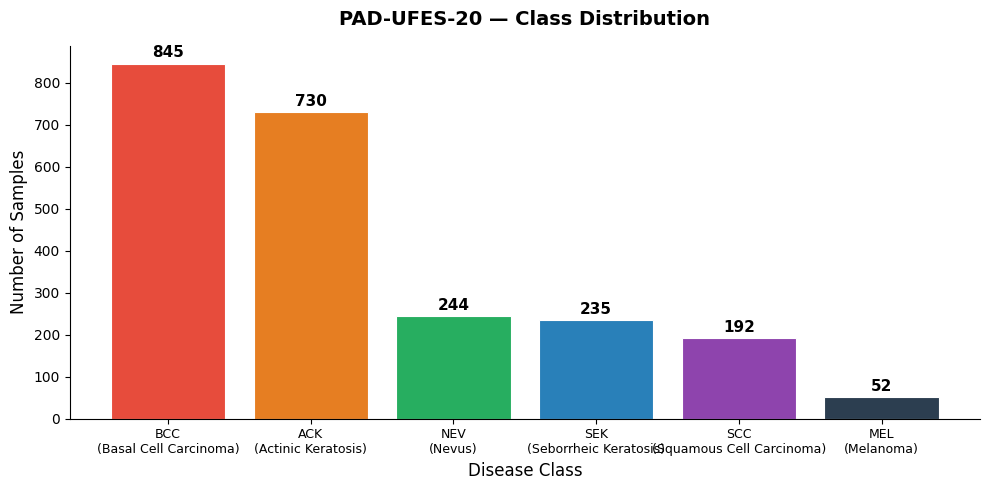

Plot 1 saved: class_distribution.png


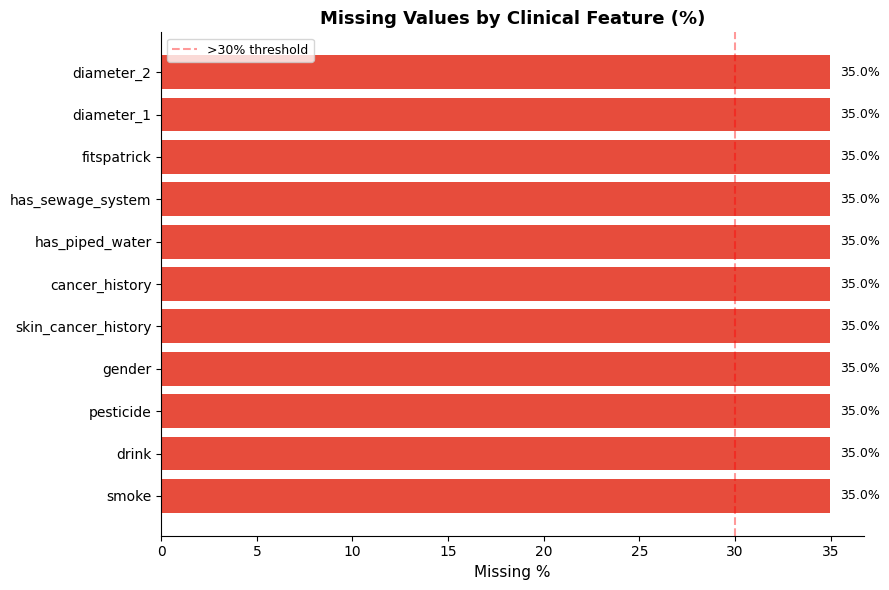

Plot 2 saved: missing_values.png


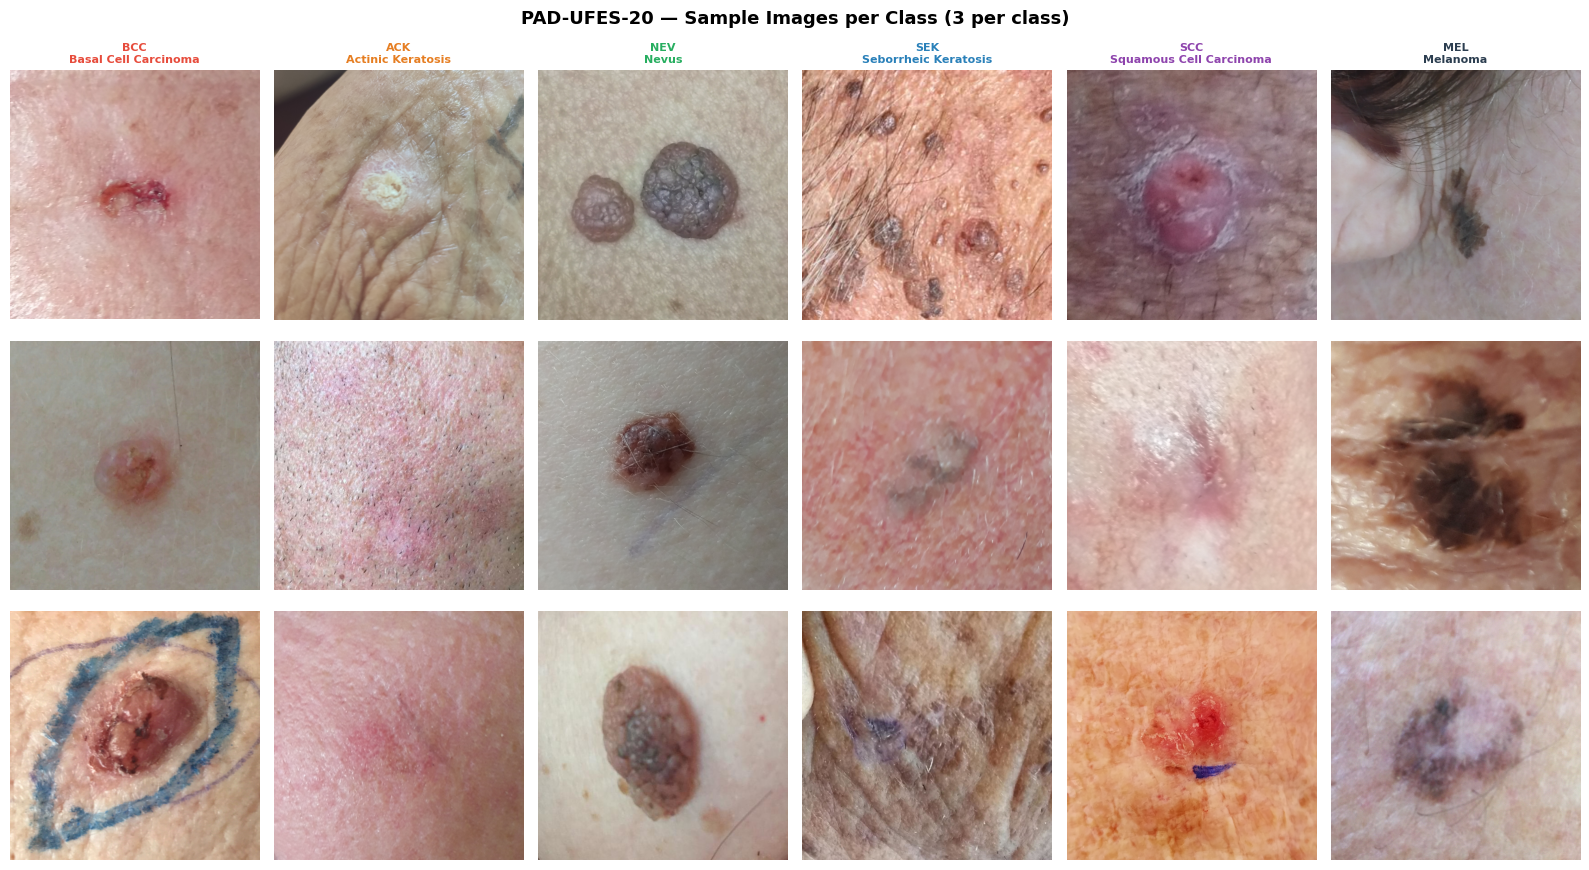

Plot 3 saved: sample_images.png


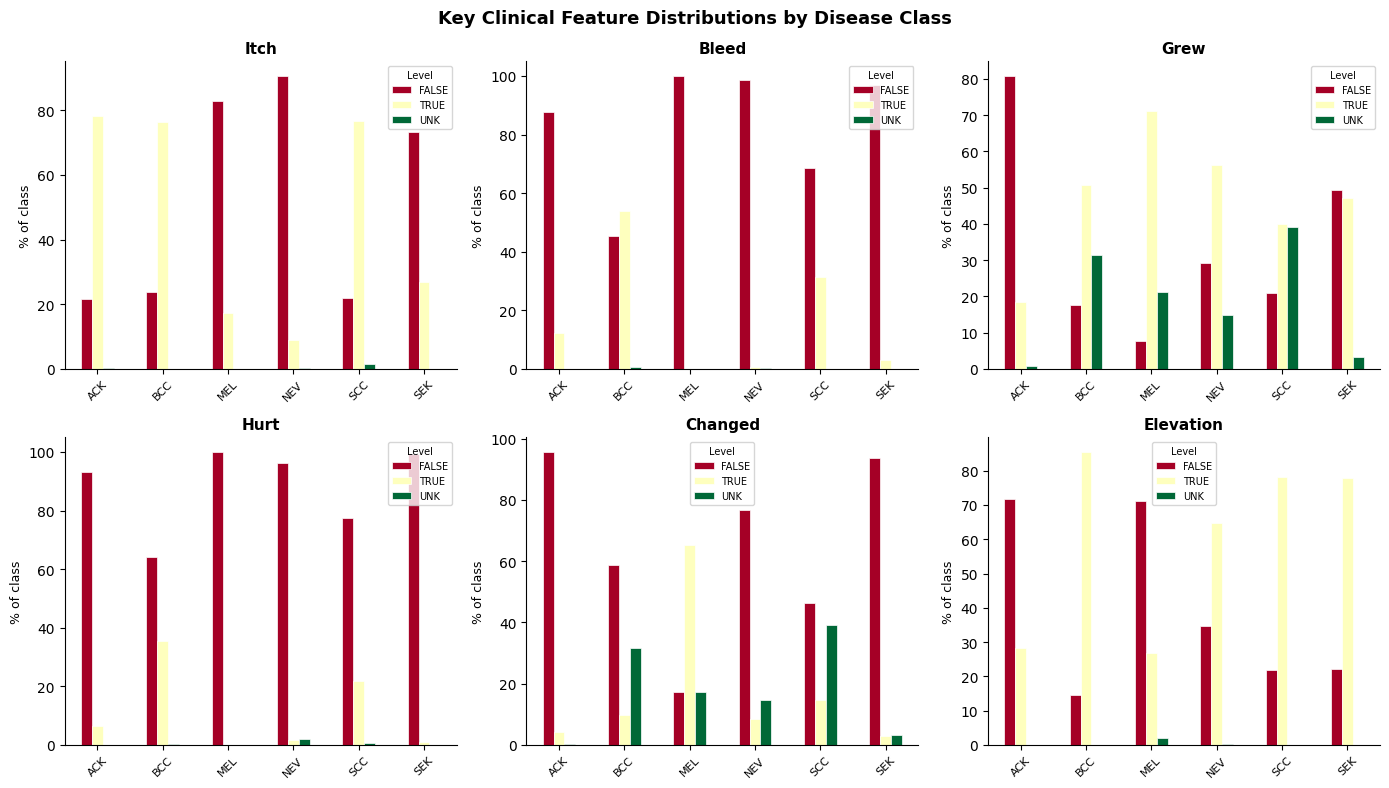

Plot 4 saved: clinical_distributions.png


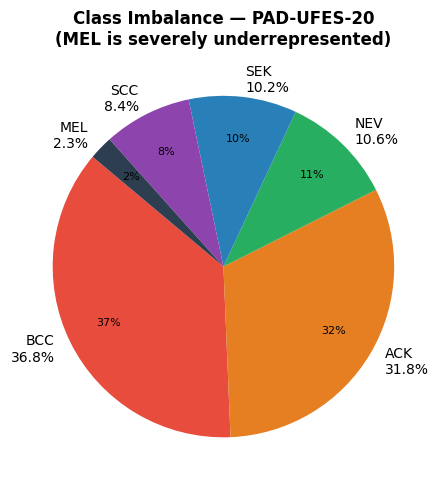

Plot 5 saved: class_imbalance_pie.png

EDA SUMMARY — Use these numbers in your paper
Total samples      : 2298
Total images       : 2298
Clinical features  : 20
Majority class     : BCC = 845 (36.8%)
Minority class     : MEL = 52 (2.3%)
Imbalance ratio    : 16.2:1 (BCC:MEL)
Samples w/ missing : 804 (35.0% of dataset)
Complete samples   : 1494 (65.0% of dataset)

All 5 EDA plots saved to /kaggle/working/dermafusion/outputs/plots/
Phase 1 EDA complete. Ready for Phase 2 — preprocessing.


In [9]:
# ── Phase 1: Complete EDA ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import os, random

# ── Paths ──────────────────────────────────────────────
BASE     = "/kaggle/input/datasets/mahdavi1202/skin-cancer"
META     = f"{BASE}/metadata.csv"
IMG_DIRS = [
    f"{BASE}/imgs_part_1/imgs_part_1",
    f"{BASE}/imgs_part_2/imgs_part_2",
    f"{BASE}/imgs_part_3/imgs_part_3",
]
OUT = "/kaggle/working/dermafusion/outputs/plots"
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(META)

# build image lookup: filename → full path
img_map = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        img_map[fname] = os.path.join(d, fname)

CLASS_COLORS = {
    "BCC": "#E74C3C", "ACK": "#E67E22", "NEV": "#27AE60",
    "SEK": "#2980B9", "SCC": "#8E44AD", "MEL": "#2C3E50"
}
FULL_NAMES = {
    "BCC": "Basal Cell Carcinoma",
    "ACK": "Actinic Keratosis",
    "NEV": "Nevus",
    "SEK": "Seborrheic Keratosis",
    "SCC": "Squamous Cell Carcinoma",
    "MEL": "Melanoma"
}

print("Starting EDA — generating all plots...\n")

# ── Plot 1: Class Distribution ─────────────────────────
counts = df["diagnostic"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index,
              counts.values,
              color=[CLASS_COLORS[c] for c in counts.index],
              edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("PAD-UFES-20 — Class Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Disease Class", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([f"{c}\n({FULL_NAMES[c]})" for c in counts.index], fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 1 saved: class_distribution.png")

# ── Plot 2: Missing Values ─────────────────────────────
CLINICAL = ["smoke","drink","age","pesticide","gender","skin_cancer_history",
            "cancer_history","has_piped_water","has_sewage_system",
            "fitspatrick","region","diameter_1","diameter_2",
            "itch","grew","hurt","changed","bleed","elevation","biopsed"]
missing_pct = df[CLINICAL].isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E74C3C" if v > 30 else "#E67E22" if v > 10 else "#27AE60"
          for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
ax.set_title("Missing Values by Clinical Feature (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Missing %", fontsize=11)
ax.axvline(30, color="red", linestyle="--", alpha=0.4, label=">30% threshold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 2 saved: missing_values.png")

# ── Plot 3: Sample images per class ───────────────────
fig, axes = plt.subplots(3, 6, figsize=(16, 9))
fig.suptitle("PAD-UFES-20 — Sample Images per Class (3 per class)",
             fontsize=13, fontweight="bold")
for col, cls in enumerate(["BCC","ACK","NEV","SEK","SCC","MEL"]):
    samples = df[df["diagnostic"] == cls]["img_id"].tolist()
    chosen  = random.sample(samples, min(3, len(samples)))
    for row, img_id in enumerate(chosen):
        ax = axes[row][col]
        if img_id in img_map:
            img = Image.open(img_map[img_id]).convert("RGB")
            ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"{cls}\n{FULL_NAMES[cls]}",
                         fontsize=8, fontweight="bold",
                         color=CLASS_COLORS[cls])
plt.tight_layout()
plt.savefig(f"{OUT}/sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 3 saved: sample_images.png")

# ── Plot 4: Clinical Feature Distributions ─────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Key Clinical Feature Distributions by Disease Class",
             fontsize=13, fontweight="bold")
features = ["itch","bleed","grew","hurt","changed","elevation"]
labels   = ["Itch","Bleed","Grew","Hurt","Changed","Elevation"]
df_clean = df.dropna(subset=features)

for ax, feat, lbl in zip(axes.flat, features, labels):
    ct = pd.crosstab(df_clean["diagnostic"], df_clean[feat], normalize="index") * 100
    ct.plot(kind="bar", ax=ax, colormap="RdYlGn", edgecolor="white", linewidth=0.5)
    ax.set_title(lbl, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% of class", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(title="Level", fontsize=7, title_fontsize=7)
    ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/clinical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 4 saved: clinical_distributions.png")

# ── Plot 5: Class imbalance ratio ─────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
total = counts.sum()
pcts  = (counts / total * 100).round(1)
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=[f"{c}\n{p}%" for c, p in zip(counts.index, pcts)],
    colors=[CLASS_COLORS[c] for c in counts.index],
    autopct="%1.0f%%", startangle=140,
    pctdistance=0.75, textprops={"fontsize":10}
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title("Class Imbalance — PAD-UFES-20\n(MEL is severely underrepresented)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT}/class_imbalance_pie.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot 5 saved: class_imbalance_pie.png")

# ── Summary stats for paper ────────────────────────────
print("\n" + "="*55)
print("EDA SUMMARY — Use these numbers in your paper")
print("="*55)
print(f"Total samples      : {len(df)}")
print(f"Total images       : {len(img_map)}")
print(f"Clinical features  : {len(CLINICAL)}")
print(f"Majority class     : BCC = {counts['BCC']} ({counts['BCC']/len(df)*100:.1f}%)")
print(f"Minority class     : MEL = {counts['MEL']} ({counts['MEL']/len(df)*100:.1f}%)")
print(f"Imbalance ratio    : {counts['BCC']/counts['MEL']:.1f}:1 (BCC:MEL)")
print(f"Samples w/ missing : 804 ({804/len(df)*100:.1f}% of dataset)")
print(f"Complete samples   : {len(df)-804} ({(len(df)-804)/len(df)*100:.1f}% of dataset)")
print("="*55)
print("\nAll 5 EDA plots saved to /kaggle/working/dermafusion/outputs/plots/")
print("Phase 1 EDA complete. Ready for Phase 2 — preprocessing.")

In [10]:
# ── Phase 2 / Cell 4: Stratified Train-Val-Test Split ──
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
META = "/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv"
df = pd.read_csv(META)

CLINICAL_COLS = ["smoke","drink","pesticide","gender","skin_cancer_history",
                  "cancer_history","has_piped_water","has_sewage_system",
                  "fitspatrick","diameter_1","diameter_2"]

df_complete = df.dropna(subset=CLINICAL_COLS).reset_index(drop=True)
print(f"Full dataset: {len(df)} | Complete-clinical subset: {len(df_complete)}")

train_df, temp_df = train_test_split(
    df_complete, test_size=0.30, stratify=df_complete["diagnostic"], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["diagnostic"], random_state=RANDOM_SEED
)

train_df = train_df.copy(); train_df["split"] = "train"
val_df   = val_df.copy();   val_df["split"]   = "val"
test_df  = test_df.copy();  test_df["split"]  = "test"

split_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)
SPLIT_PATH = "/kaggle/working/dermafusion/data/split.csv"
split_df.to_csv(SPLIT_PATH, index=False)

print(f"\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("\nClass distribution per split:")
print(pd.crosstab(split_df["diagnostic"], split_df["split"]))
print(f"\nSplit saved. This EXACT split is reused for every model in Phases 2-5.")

Full dataset: 2298 | Complete-clinical subset: 1494

Train: 1045  Val: 224  Test: 225

Class distribution per split:
split       test  train  val
diagnostic                  
ACK           43    198   42
BCC          127    591  127
MEL            8     36    8
NEV           11     53   11
SCC           29    134   29
SEK            7     33    7

Split saved. This EXACT split is reused for every model in Phases 2-5.


In [11]:
# ── Cell 5: PyTorch Dataset + Dataloaders ───────────────
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

IMG_DIRS = [
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_1/imgs_part_1",
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_2/imgs_part_2",
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_3/imgs_part_3",
]
img_map = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        img_map[fname] = os.path.join(d, fname)

CLASSES = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class SkinImageDataset(Dataset):
    def __init__(self, df, img_map, transform):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_map[row["img_id"]]).convert("RGB")
        return self.transform(img), CLASS_TO_IDX[row["diagnostic"]]

split_df = pd.read_csv("/kaggle/working/dermafusion/data/split.csv")
train_df = split_df[split_df["split"] == "train"]
val_df   = split_df[split_df["split"] == "val"]
test_df  = split_df[split_df["split"] == "test"]

train_loader = DataLoader(SkinImageDataset(train_df, img_map, train_transform), batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(SkinImageDataset(val_df,   img_map, eval_transform),  batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(SkinImageDataset(test_df,  img_map, eval_transform),  batch_size=32, shuffle=False, num_workers=2)

class_counts = train_df["diagnostic"].value_counts().reindex(CLASSES)
class_weights = (1.0 / class_counts) * class_counts.sum() / len(CLASSES)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)

print(f"Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}")
print("\nClass weights (for imbalance):")
print(class_weights.round(2))

Train batches: 33  Val: 7  Test: 8

Class weights (for imbalance):
diagnostic
ACK    0.88
BCC    0.29
MEL    4.84
NEV    3.29
SCC    1.30
SEK    5.28
Name: count, dtype: float64


In [12]:
# ── Cell 6: ResNet50 Model + Training ───────────────────
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class ImageOnlyModel(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        backbone.fc = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, num_classes)
        )
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(x)

model = ImageOnlyModel(6).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam([
    {"params": model.backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model.backbone.fc.parameters(),     "lr": 1e-4},
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train: optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader.dataset), f1_score(all_labels, all_preds, average="macro")

EPOCHS, PATIENCE = 100, 10
best_val_f1, patience_counter = 0, 0
os.makedirs("/kaggle/working/dermafusion/checkpoints", exist_ok=True)
CKPT_PATH = "/kaggle/working/dermafusion/checkpoints/baseline1_image_only.pt"

print("Starting training...\n")
start = time.time()
for epoch in range(1, EPOCHS+1):
    train_loss, train_f1 = run_epoch(train_loader, True)
    val_loss, val_f1 = run_epoch(val_loader, False)
    scheduler.step(val_f1)
    marker = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        marker = " ← saved"
    else:
        patience_counter += 1
    print(f"Epoch {epoch:3d} | Train F1 {train_f1:.4f} | Val F1 {val_f1:.4f}{marker}")
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nTraining done in {(time.time()-start)/60:.1f} min | Best Val F1: {best_val_f1:.4f}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Starting training...

Epoch   1 | Train F1 0.1826 | Val F1 0.2338 ← saved
Epoch   2 | Train F1 0.2886 | Val F1 0.3012 ← saved
Epoch   3 | Train F1 0.3932 | Val F1 0.3822 ← saved
Epoch   4 | Train F1 0.3157 | Val F1 0.3641
Epoch   5 | Train F1 0.4029 | Val F1 0.3327
Epoch   6 | Train F1 0.4525 | Val F1 0.3933 ← saved
Epoch   7 | Train F1 0.4634 | Val F1 0.3935 ← saved
Epoch   8 | Train F1 0.4759 | Val F1 0.4501 ← saved
Epoch   9 | Train F1 0.5285 | Val F1 0.4154
Epoch  10 | Train F1 0.5631 | Val F1 0.4665 ← saved
Epoch  11 | Train F1 0.5615 | Val F1 0.4588
Epoch  12 | Train F1 0.5828 | Val F1 0.4703 ← saved
Epoch  13 | Train F1 0.6116 | Val F1 0.4882 ← saved
Epoch  14 | Train F1 0.6065 | Val F1 0.4860
Epoch  15 | Train F1 0.6034 | Val F1 0.5410 ← saved
Epoch  16 | Train F1 0.6407 | Val F1 0.5476 ← saved
Epoch  17 | Train F1 0.6660 | Val F1 0.5451
Epoch  18 | Train F1 0.6643 | Val F1 0.5754 ← saved
Epoch  19 | Train F1 0.6931 | Val F1 0.5559
Epoch  20 | Train F1 0.6891 | Val F1 0.5801 ← 

BASELINE 1 — IMAGE-ONLY — TEST RESULTS
Accuracy: 56.89%  Macro F1: 51.06%  Weighted F1: 58.31%

  ACK: P 47.7%  R 48.8%  F1 48.3%  (n=43)
  BCC: P 75.0%  R 63.8%  F1 68.9%  (n=127)
  MEL: P 62.5%  R 62.5%  F1 62.5%  (n=8)
  NEV: P 57.1%  R 72.7%  F1 64.0%  (n=11)
  SCC: P 23.9%  R 37.9%  F1 29.3%  (n=29)
  SEK: P 40.0%  R 28.6%  F1 33.3%  (n=7)


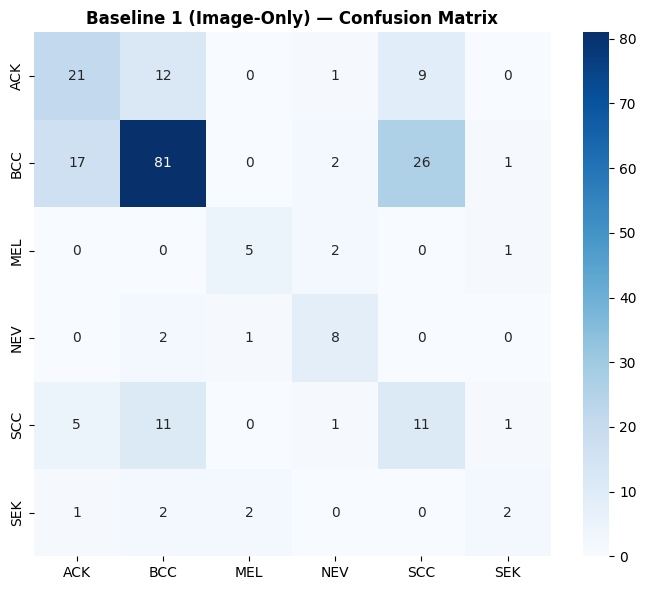


Saved. This is Row 1 of your ablation table.
Phase 2 complete. Ready for Phase 3 — clinical-only baseline.


In [13]:
# ── Cell 7: Evaluate Baseline 1 on Test Set ─────────────
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

model.load_state_dict(torch.load(CKPT_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

acc = (np.array(all_preds) == np.array(all_labels)).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(6))

print(f"BASELINE 1 — IMAGE-ONLY — TEST RESULTS")
print(f"Accuracy: {acc*100:.2f}%  Macro F1: {macro_f1*100:.2f}%  Weighted F1: {weighted_f1*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

os.makedirs("/kaggle/working/dermafusion/outputs/plots", exist_ok=True)
os.makedirs("/kaggle/working/dermafusion/outputs/results", exist_ok=True)

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Baseline 1 (Image-Only) — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/baseline1_confusion_matrix.png", dpi=150)
plt.show()

results = {"model_name": "Baseline 1 - Image Only (ResNet50)", "accuracy": float(acc),
           "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}
with open("/kaggle/working/dermafusion/outputs/results/baseline1_image_only.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved. This is Row 1 of your ablation table.")
print("Phase 2 complete. Ready for Phase 3 — clinical-only baseline.")

In [14]:
# ── Phase 3 / Cell 8: Clinical-Only Preprocessing ───────
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

split_df = pd.read_csv("/kaggle/working/dermafusion/data/split.csv")

NUMERIC_COLS = ["age", "diameter_1", "diameter_2"]
CATEGORICAL_COLS = ["smoke","drink","pesticide","gender","skin_cancer_history",
                     "cancer_history","has_piped_water","has_sewage_system",
                     "fitspatrick","region","itch","grew","hurt","changed",
                     "bleed","elevation","biopsed"]
CLINICAL_FEATURES = NUMERIC_COLS + CATEGORICAL_COLS
print(f"Total clinical features: {len(CLINICAL_FEATURES)}")

split_df[NUMERIC_COLS] = split_df[NUMERIC_COLS].astype(float)   # ← fix added here

encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    split_df[col] = le.fit_transform(split_df[col].astype(str))
    encoders[col] = le

train_mask = split_df["split"] == "train"
scaler = StandardScaler()
split_df.loc[train_mask, NUMERIC_COLS] = scaler.fit_transform(split_df.loc[train_mask, NUMERIC_COLS])
split_df.loc[~train_mask, NUMERIC_COLS] = scaler.transform(split_df.loc[~train_mask, NUMERIC_COLS])

split_df.to_csv("/kaggle/working/dermafusion/data/split_clinical_encoded.csv", index=False)

train_df = split_df[split_df["split"] == "train"]
val_df   = split_df[split_df["split"] == "val"]
test_df  = split_df[split_df["split"] == "test"]
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("\nSample encoded row:")
print(train_df[CLINICAL_FEATURES].iloc[0])

Total clinical features: 20
Train: 1045  Val: 224  Test: 225

Sample encoded row:
age                   -0.673199
diameter_1            -0.215761
diameter_2             0.025121
smoke                  0.000000
drink                  0.000000
pesticide              1.000000
gender                 0.000000
skin_cancer_history    0.000000
cancer_history         1.000000
has_piped_water        0.000000
has_sewage_system      0.000000
fitspatrick            1.000000
region                 2.000000
itch                   1.000000
grew                   1.000000
hurt                   1.000000
changed                0.000000
bleed                  1.000000
elevation              1.000000
biopsed                1.000000
Name: 0, dtype: float64


In [15]:
# ── Cell 9: Clinical-Only Dataset + Balanced Sampler ────
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

CLASSES = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

class ClinicalDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.features = df[feature_cols].values.astype(np.float32)
        self.labels = df["diagnostic"].map(CLASS_TO_IDX).values
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), self.labels[idx]

train_ds_c = ClinicalDataset(train_df, CLINICAL_FEATURES)

# Force every batch to see a balanced mix of all 6 classes
sample_labels = train_ds_c.labels
class_sample_counts = np.array([np.sum(sample_labels == i) for i in range(6)])
sample_weights = 1.0 / class_sample_counts[sample_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_c = DataLoader(train_ds_c, batch_size=32, sampler=sampler)
val_loader_c   = DataLoader(ClinicalDataset(val_df, CLINICAL_FEATURES),   batch_size=32, shuffle=False)
test_loader_c  = DataLoader(ClinicalDataset(test_df, CLINICAL_FEATURES), batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader_c)}  Val: {len(val_loader_c)}  Test: {len(test_loader_c)}")
print("Sampler active — every batch now sees a balanced mix of classes.")

Train batches: 33  Val: 7  Test: 8
Sampler active — every batch now sees a balanced mix of classes.


In [16]:
# ── Cell 10: Clinical MLP v2 — Stabilized Training ──────
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score
import os, time

class ClinicalMLP(nn.Module):
    def __init__(self, input_dim, num_classes=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(256, num_classes))
    def forward(self, x):
        return self.classifier(self.encoder(x))

model_c = ClinicalMLP(input_dim=len(CLINICAL_FEATURES)).to(device)
criterion_c = nn.CrossEntropyLoss()   # sampler already balances classes — no need to double-correct with weights
optimizer_c = optim.Adam(model_c.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(optimizer_c, mode="max", factor=0.5, patience=7)

def run_epoch_c(loader, train=True):
    model_c.train() if train else model_c.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.set_grad_enabled(train):
        for feats, labels in loader:
            feats, labels = feats.to(device), labels.to(device)
            if train: optimizer_c.zero_grad()
            outputs = model_c(feats)
            loss = criterion_c(outputs, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_c.parameters(), max_norm=1.0)
                optimizer_c.step()
            total_loss += loss.item() * feats.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/len(loader.dataset), f1_score(all_labels, all_preds, average="macro")

EPOCHS, PATIENCE = 150, 15
best_val_f1_c, patience_counter = 0, 0
os.makedirs("/kaggle/working/dermafusion/checkpoints", exist_ok=True)
CKPT_PATH_C = "/kaggle/working/dermafusion/checkpoints/baseline2_clinical_only.pt"

print("Starting training (clinical-only MLP v2)...\n")
start = time.time()
for epoch in range(1, EPOCHS+1):
    train_loss, train_f1 = run_epoch_c(train_loader_c, True)
    val_loss, val_f1 = run_epoch_c(val_loader_c, False)
    scheduler_c.step(val_f1)
    marker = ""
    if val_f1 > best_val_f1_c:
        best_val_f1_c = val_f1
        patience_counter = 0
        torch.save(model_c.state_dict(), CKPT_PATH_C)
        marker = " ← saved"
    else:
        patience_counter += 1
    print(f"Epoch {epoch:3d} | Train F1 {train_f1:.4f} | Val F1 {val_f1:.4f}{marker}")
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nTraining done in {(time.time()-start)/60:.1f} min | Best Val F1: {best_val_f1_c:.4f}")

Starting training (clinical-only MLP v2)...

Epoch   1 | Train F1 0.3148 | Val F1 0.2925 ← saved
Epoch   2 | Train F1 0.4636 | Val F1 0.3666 ← saved
Epoch   3 | Train F1 0.5040 | Val F1 0.3762 ← saved
Epoch   4 | Train F1 0.5741 | Val F1 0.4425 ← saved
Epoch   5 | Train F1 0.5763 | Val F1 0.4487 ← saved
Epoch   6 | Train F1 0.5939 | Val F1 0.4677 ← saved
Epoch   7 | Train F1 0.6186 | Val F1 0.4534
Epoch   8 | Train F1 0.6444 | Val F1 0.5282 ← saved
Epoch   9 | Train F1 0.6472 | Val F1 0.5493 ← saved
Epoch  10 | Train F1 0.6724 | Val F1 0.4903
Epoch  11 | Train F1 0.6777 | Val F1 0.5380
Epoch  12 | Train F1 0.7039 | Val F1 0.5341
Epoch  13 | Train F1 0.6965 | Val F1 0.5323
Epoch  14 | Train F1 0.6920 | Val F1 0.5221
Epoch  15 | Train F1 0.7183 | Val F1 0.5328
Epoch  16 | Train F1 0.6839 | Val F1 0.5371
Epoch  17 | Train F1 0.7215 | Val F1 0.5515 ← saved
Epoch  18 | Train F1 0.7188 | Val F1 0.5972 ← saved
Epoch  19 | Train F1 0.7336 | Val F1 0.5993 ← saved
Epoch  20 | Train F1 0.7052 | V

BASELINE 2 — CLINICAL-ONLY (MLP) — TEST RESULTS
Accuracy: 64.44%  Macro F1: 56.56%  Weighted F1: 66.30%

  ACK: P 66.0%  R 72.1%  F1 68.9%  (n=43)
  BCC: P 84.0%  R 66.1%  F1 74.0%  (n=127)
  MEL: P 37.5%  R 37.5%  F1 37.5%  (n=8)
  NEV: P 71.4%  R 45.5%  F1 55.6%  (n=11)
  SCC: P 31.6%  R 62.1%  F1 41.9%  (n=29)
  SEK: P 66.7%  R 57.1%  F1 61.5%  (n=7)


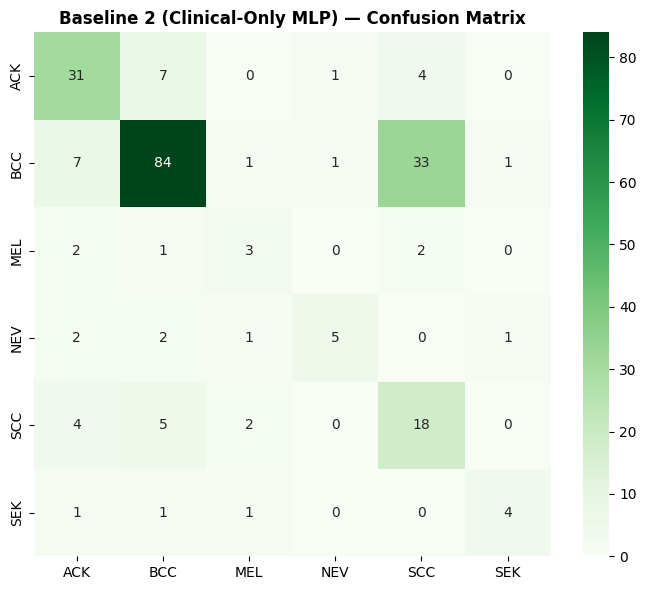


Saved. This is Row 2 of your ablation table.

Baseline 1 (Image-only):    Macro F1 = 50.23%
Baseline 2 (Clinical-only): Macro F1 = 56.56%

Phase 3 complete. Ready for Phase 4 — concatenation fusion.


In [17]:
# ── Cell 11: Evaluate Baseline 2 on Test Set ────────────
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json

model_c.load_state_dict(torch.load(CKPT_PATH_C))
model_c.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for feats, labels in test_loader_c:
        preds = model_c(feats.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

acc = (np.array(all_preds) == np.array(all_labels)).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(6))

print(f"BASELINE 2 — CLINICAL-ONLY (MLP) — TEST RESULTS")
print(f"Accuracy: {acc*100:.2f}%  Macro F1: {macro_f1*100:.2f}%  Weighted F1: {weighted_f1*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Baseline 2 (Clinical-Only MLP) — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/baseline2_confusion_matrix.png", dpi=150)
plt.show()

results = {"model_name": "Baseline 2 - Clinical Only (MLP)", "accuracy": float(acc),
           "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}
with open("/kaggle/working/dermafusion/outputs/results/baseline2_clinical_only.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved. This is Row 2 of your ablation table.")
print(f"\nBaseline 1 (Image-only):    Macro F1 = 50.23%")
print(f"Baseline 2 (Clinical-only): Macro F1 = {macro_f1*100:.2f}%")
print("\nPhase 3 complete. Ready for Phase 4 — concatenation fusion.")

In [18]:
# ── Phase 4 / Cell 12: Concatenation Fusion — Dataset + Dataloaders ──
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import os

fusion_df = pd.read_csv("/kaggle/working/dermafusion/data/split_clinical_encoded.csv")

CLINICAL_FEATURES = ["age", "diameter_1", "diameter_2", "smoke","drink","pesticide",
                      "gender","skin_cancer_history","cancer_history","has_piped_water",
                      "has_sewage_system","fitspatrick","region","itch","grew","hurt",
                      "changed","bleed","elevation","biopsed"]

CLASSES = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

class FusionDataset(Dataset):
    def __init__(self, df, img_map, feature_cols, transform):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.feature_cols = feature_cols
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_map[row["img_id"]]).convert("RGB")
        img = self.transform(img)
        clinical = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        label = CLASS_TO_IDX[row["diagnostic"]]
        return img, clinical, label

train_fdf = fusion_df[fusion_df["split"] == "train"].reset_index(drop=True)
val_fdf   = fusion_df[fusion_df["split"] == "val"].reset_index(drop=True)
test_fdf  = fusion_df[fusion_df["split"] == "test"].reset_index(drop=True)

train_fusion_ds = FusionDataset(train_fdf, img_map, CLINICAL_FEATURES, train_transform)

fusion_labels = train_fdf["diagnostic"].map(CLASS_TO_IDX).values
class_sample_counts = np.array([np.sum(fusion_labels == i) for i in range(6)])
sample_weights = 1.0 / class_sample_counts[fusion_labels]
fusion_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_f = DataLoader(train_fusion_ds, batch_size=32, sampler=fusion_sampler, num_workers=2)
val_loader_f   = DataLoader(FusionDataset(val_fdf, img_map, CLINICAL_FEATURES, eval_transform), batch_size=32, shuffle=False, num_workers=2)
test_loader_f  = DataLoader(FusionDataset(test_fdf, img_map, CLINICAL_FEATURES, eval_transform), batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader_f)}  Val: {len(val_loader_f)}  Test: {len(test_loader_f)}")
print("Balanced sampler active — same fix that solved Baseline 2's class collapse.")

Train batches: 33  Val: 7  Test: 8
Balanced sampler active — same fix that solved Baseline 2's class collapse.


In [19]:
# ── Cell 13: Concatenation Fusion Model + Training ──────
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score
import time

class ConcatFusionModel(nn.Module):
    def __init__(self, clinical_dim, num_classes=6):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        backbone.fc = nn.Identity()
        self.image_backbone = backbone
        self.image_proj = nn.Sequential(nn.Linear(2048, 512), nn.ReLU())

        self.clinical_encoder = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 + 256, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, clinical):
        img_feat = self.image_proj(self.image_backbone(img))
        clin_feat = self.clinical_encoder(clinical)
        fused = torch.cat([img_feat, clin_feat], dim=1)
        return self.classifier(fused)

model_f = ConcatFusionModel(clinical_dim=len(CLINICAL_FEATURES)).to(device)
criterion_f = nn.CrossEntropyLoss()
optimizer_f = optim.Adam([
    {"params": model_f.image_backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model_f.image_proj.parameters(),            "lr": 1e-4},
    {"params": model_f.clinical_encoder.parameters(),       "lr": 1e-4},
    {"params": model_f.classifier.parameters(),             "lr": 1e-4},
], weight_decay=1e-4)
scheduler_f = optim.lr_scheduler.ReduceLROnPlateau(optimizer_f, mode="max", factor=0.5, patience=6)

def run_epoch_f(loader, train=True):
    model_f.train() if train else model_f.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.set_grad_enabled(train):
        for imgs, clinical, labels in loader:
            imgs, clinical, labels = imgs.to(device), clinical.to(device), labels.to(device)
            if train: optimizer_f.zero_grad()
            outputs = model_f(imgs, clinical)
            loss = criterion_f(outputs, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_f.parameters(), max_norm=1.0)
                optimizer_f.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro = f1_score(all_labels, all_preds, average="macro")
    weighted = f1_score(all_labels, all_preds, average="weighted")
    return total_loss/len(loader.dataset), macro, weighted

EPOCHS, PATIENCE = 100, 12
best_val_f1, patience_counter = 0, 0
os.makedirs("/kaggle/working/dermafusion/checkpoints", exist_ok=True)
CKPT_PATH_F = "/kaggle/working/dermafusion/checkpoints/fusion_concat.pt"

print("Starting training (concatenation fusion)...\n")
start = time.time()
for epoch in range(1, EPOCHS+1):
    train_loss, train_macro, train_weighted = run_epoch_f(train_loader_f, True)
    val_loss, val_macro, val_weighted = run_epoch_f(val_loader_f, False)
    scheduler_f.step(val_macro)
    marker = ""
    if val_macro > best_val_f1:
        best_val_f1 = val_macro
        patience_counter = 0
        torch.save(model_f.state_dict(), CKPT_PATH_F)
        marker = " ← saved"
    else:
        patience_counter += 1
    print(f"Epoch {epoch:3d} | Train Macro F1 {train_macro:.4f} | Val Macro F1 {val_macro:.4f} | Val Weighted F1 {val_weighted:.4f}{marker}")
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nTraining done in {(time.time()-start)/60:.1f} min | Best Val Macro F1: {best_val_f1:.4f}")

Starting training (concatenation fusion)...

Epoch   1 | Train Macro F1 0.2112 | Val Macro F1 0.2850 | Val Weighted F1 0.4159 ← saved
Epoch   2 | Train Macro F1 0.3863 | Val Macro F1 0.3916 | Val Weighted F1 0.2736 ← saved
Epoch   3 | Train Macro F1 0.5228 | Val Macro F1 0.5042 | Val Weighted F1 0.4200 ← saved
Epoch   4 | Train Macro F1 0.5896 | Val Macro F1 0.5853 | Val Weighted F1 0.6460 ← saved
Epoch   5 | Train Macro F1 0.6301 | Val Macro F1 0.5553 | Val Weighted F1 0.6141
Epoch   6 | Train Macro F1 0.6415 | Val Macro F1 0.5095 | Val Weighted F1 0.4751
Epoch   7 | Train Macro F1 0.6537 | Val Macro F1 0.5627 | Val Weighted F1 0.5455
Epoch   8 | Train Macro F1 0.7131 | Val Macro F1 0.5967 | Val Weighted F1 0.6781 ← saved
Epoch   9 | Train Macro F1 0.7457 | Val Macro F1 0.5092 | Val Weighted F1 0.4924
Epoch  10 | Train Macro F1 0.7500 | Val Macro F1 0.5391 | Val Weighted F1 0.5469
Epoch  11 | Train Macro F1 0.7705 | Val Macro F1 0.5515 | Val Weighted F1 0.5484
Epoch  12 | Train Macro 

CONCATENATION FUSION — TEST RESULTS
Accuracy: 66.67%  Macro F1: 57.66%  Weighted F1: 65.01%

  ACK: P 55.6%  R 58.1%  F1 56.8%  (n=43)
  BCC: P 75.2%  R 81.1%  F1 78.0%  (n=127)
  MEL: P 60.0%  R 75.0%  F1 66.7%  (n=8)
  NEV: P 54.5%  R 54.5%  F1 54.5%  (n=11)
  SCC: P 35.7%  R 17.2%  F1 23.3%  (n=29)
  SEK: P 62.5%  R 71.4%  F1 66.7%  (n=7)


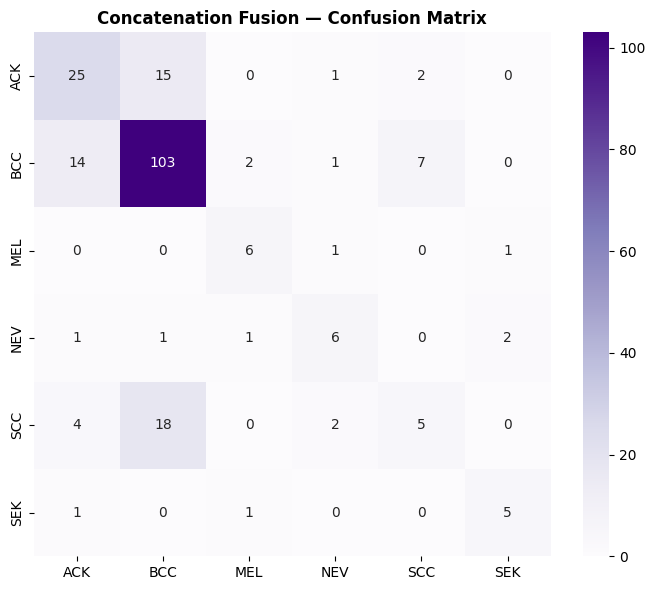


Saved. This is Row 3 of your ablation table.

ABLATION TABLE SO FAR
Baseline 1 (Image-only):     Macro F1 = 50.23%
Baseline 2 (Clinical-only):  Macro F1 = 52.08%
Concat Fusion (Row 3):       Macro F1 = 57.66%

Phase 4 complete. Ready for Phase 5 — attention fusion (your main contribution).


In [20]:
# ── Cell 14: Evaluate Concatenation Fusion on Test Set ──
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json

model_f.load_state_dict(torch.load(CKPT_PATH_F))
model_f.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, clinical, labels in test_loader_f:
        preds = model_f(imgs.to(device), clinical.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

acc = (np.array(all_preds) == np.array(all_labels)).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(6))

print(f"CONCATENATION FUSION — TEST RESULTS")
print(f"Accuracy: {acc*100:.2f}%  Macro F1: {macro_f1*100:.2f}%  Weighted F1: {weighted_f1*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Concatenation Fusion — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/fusion_concat_confusion_matrix.png", dpi=150)
plt.show()

results = {"model_name": "Concatenation Fusion (Image+Clinical)", "accuracy": float(acc),
           "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}
with open("/kaggle/working/dermafusion/outputs/results/fusion_concat.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved. This is Row 3 of your ablation table.\n")
print("="*55)
print("ABLATION TABLE SO FAR")
print("="*55)
print(f"Baseline 1 (Image-only):     Macro F1 = 50.23%")
print(f"Baseline 2 (Clinical-only):  Macro F1 = 52.08%")
print(f"Concat Fusion (Row 3):       Macro F1 = {macro_f1*100:.2f}%")
print("="*55)
print("\nPhase 4 complete. Ready for Phase 5 — attention fusion (your main contribution).")

In [21]:
# ── Phase 5 / Cell 15: Attention Fusion — Seed + Fixed Preprocessing ──
import torch
import numpy as np
import random
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import os

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seed fixed at 42 — Phase 4 vs Phase 5 comparison is now clean.")

split_df = pd.read_csv("/kaggle/working/dermafusion/data/split.csv")

NUMERIC_COLS = ["age", "diameter_1", "diameter_2"]
BINARY_ORDINAL_COLS = ["smoke","drink","pesticide","gender","skin_cancer_history",
                        "cancer_history","has_piped_water","has_sewage_system",
                        "fitspatrick","itch","grew","hurt","changed","bleed",
                        "elevation","biopsed"]

split_df[NUMERIC_COLS] = split_df[NUMERIC_COLS].astype(float)

for col in BINARY_ORDINAL_COLS:
    le = LabelEncoder()
    split_df[col] = le.fit_transform(split_df[col].astype(str))

region_dummies = pd.get_dummies(split_df["region"].astype(str), prefix="region")
split_df = pd.concat([split_df, region_dummies], axis=1)

train_mask = split_df["split"] == "train"
scaler = StandardScaler()
split_df.loc[train_mask, NUMERIC_COLS] = scaler.fit_transform(split_df.loc[train_mask, NUMERIC_COLS])
split_df.loc[~train_mask, NUMERIC_COLS] = scaler.transform(split_df.loc[~train_mask, NUMERIC_COLS])

CLINICAL_FEATURES_V2 = NUMERIC_COLS + BINARY_ORDINAL_COLS + list(region_dummies.columns)
print(f"Clinical features: {len(CLINICAL_FEATURES_V2)} (region now one-hot, {len(region_dummies.columns)} columns instead of 1)")

split_df.to_csv("/kaggle/working/dermafusion/data/split_clinical_encoded_v2.csv", index=False)

CLASSES = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])

class FusionDatasetV2(Dataset):
    def __init__(self, df, img_map, feature_cols, transform):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.feature_cols = feature_cols
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_map[row["img_id"]]).convert("RGB")
        img = self.transform(img)
        clinical = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        label = CLASS_TO_IDX[row["diagnostic"]]
        return img, clinical, label

train_adf = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_adf   = split_df[split_df["split"] == "val"].reset_index(drop=True)
test_adf  = split_df[split_df["split"] == "test"].reset_index(drop=True)

train_attn_ds = FusionDatasetV2(train_adf, img_map, CLINICAL_FEATURES_V2, train_transform)

attn_labels = train_adf["diagnostic"].map(CLASS_TO_IDX).values
class_sample_counts = np.array([np.sum(attn_labels == i) for i in range(6)])
sample_weights = 1.0 / class_sample_counts[attn_labels]
attn_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_a = DataLoader(train_attn_ds, batch_size=32, sampler=attn_sampler, num_workers=2)
val_loader_a   = DataLoader(FusionDatasetV2(val_adf, img_map, CLINICAL_FEATURES_V2, eval_transform), batch_size=32, shuffle=False, num_workers=2)
test_loader_a  = DataLoader(FusionDatasetV2(test_adf, img_map, CLINICAL_FEATURES_V2, eval_transform), batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader_a)}  Val: {len(val_loader_a)}  Test: {len(test_loader_a)}")

Random seed fixed at 42 — Phase 4 vs Phase 5 comparison is now clean.
Clinical features: 33 (region now one-hot, 14 columns instead of 1)
Train batches: 33  Val: 7  Test: 8


In [22]:
# ── Cell 16: Image-Guided Attention Fusion Model + Training ──
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score
import time

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_loss = ((1 - p_t) ** self.gamma) * ce_loss
        return focal_loss.mean()

class AttentionFusionModel(nn.Module):
    def __init__(self, clinical_dim, num_classes=6, num_heads=8):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        for name, param in backbone.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False
        backbone.fc = nn.Identity()
        self.image_backbone = backbone
        self.image_proj = nn.Sequential(nn.Linear(2048, 512), nn.ReLU())
        self.query_proj = nn.Linear(512, 256)

        self.clinical_encoder = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 256), nn.BatchNorm1d(256), nn.ReLU(),
        )

        self.attention = nn.MultiheadAttention(embed_dim=256, num_heads=num_heads, batch_first=True)

        self.classifier = nn.Sequential(
            nn.Linear(512 + 256, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, clinical):
        img_feat = self.image_proj(self.image_backbone(img))
        clin_feat = self.clinical_encoder(clinical)

        query = self.query_proj(img_feat).unsqueeze(1)
        key_value = clin_feat.unsqueeze(1)

        attended_clinical, attn_weights = self.attention(query, key_value, key_value)
        attended_clinical = attended_clinical.squeeze(1)

        fused = torch.cat([img_feat, attended_clinical], dim=1)
        return self.classifier(fused)

model_a = AttentionFusionModel(clinical_dim=len(CLINICAL_FEATURES_V2)).to(device)
criterion_a = FocalLoss(gamma=2.0)
optimizer_a = optim.Adam([
    {"params": model_a.image_backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model_a.image_proj.parameters(),             "lr": 1e-4},
    {"params": model_a.query_proj.parameters(),              "lr": 1e-4},
    {"params": model_a.clinical_encoder.parameters(),        "lr": 1e-4},
    {"params": model_a.attention.parameters(),                "lr": 1e-4},
    {"params": model_a.classifier.parameters(),                "lr": 1e-4},
], weight_decay=1e-4)
scheduler_a = optim.lr_scheduler.ReduceLROnPlateau(optimizer_a, mode="max", factor=0.5, patience=6)

def run_epoch_a(loader, train=True):
    model_a.train() if train else model_a.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.set_grad_enabled(train):
        for imgs, clinical, labels in loader:
            imgs, clinical, labels = imgs.to(device), clinical.to(device), labels.to(device)
            if train: optimizer_a.zero_grad()
            outputs = model_a(imgs, clinical)
            loss = criterion_a(outputs, labels)
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model_a.parameters(), max_norm=1.0)
                optimizer_a.step()
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro = f1_score(all_labels, all_preds, average="macro")
    weighted = f1_score(all_labels, all_preds, average="weighted")
    return total_loss/len(loader.dataset), macro, weighted

EPOCHS, PATIENCE = 100, 12
best_val_f1, patience_counter = 0, 0
os.makedirs("/kaggle/working/dermafusion/checkpoints", exist_ok=True)
CKPT_PATH_A = "/kaggle/working/dermafusion/checkpoints/attention_fusion.pt"

print("Starting training (image-guided attention fusion)...\n")
start = time.time()
for epoch in range(1, EPOCHS+1):
    train_loss, train_macro, train_weighted = run_epoch_a(train_loader_a, True)
    val_loss, val_macro, val_weighted = run_epoch_a(val_loader_a, False)
    scheduler_a.step(val_macro)
    marker = ""
    if val_macro > best_val_f1:
        best_val_f1 = val_macro
        patience_counter = 0
        torch.save(model_a.state_dict(), CKPT_PATH_A)
        marker = " ← saved"
    else:
        patience_counter += 1
    print(f"Epoch {epoch:3d} | Train Macro F1 {train_macro:.4f} | Val Macro F1 {val_macro:.4f} | Val Weighted F1 {val_weighted:.4f}{marker}")
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nTraining done in {(time.time()-start)/60:.1f} min | Best Val Macro F1: {best_val_f1:.4f}")

Starting training (image-guided attention fusion)...

Epoch   1 | Train Macro F1 0.2290 | Val Macro F1 0.3548 | Val Weighted F1 0.4575 ← saved
Epoch   2 | Train Macro F1 0.4374 | Val Macro F1 0.4238 | Val Weighted F1 0.4855 ← saved
Epoch   3 | Train Macro F1 0.5371 | Val Macro F1 0.4606 | Val Weighted F1 0.5390 ← saved
Epoch   4 | Train Macro F1 0.6062 | Val Macro F1 0.5706 | Val Weighted F1 0.5422 ← saved
Epoch   5 | Train Macro F1 0.6586 | Val Macro F1 0.5410 | Val Weighted F1 0.4202
Epoch   6 | Train Macro F1 0.6606 | Val Macro F1 0.6363 | Val Weighted F1 0.6622 ← saved
Epoch   7 | Train Macro F1 0.7186 | Val Macro F1 0.5619 | Val Weighted F1 0.5485
Epoch   8 | Train Macro F1 0.7179 | Val Macro F1 0.5120 | Val Weighted F1 0.3709
Epoch   9 | Train Macro F1 0.7526 | Val Macro F1 0.6275 | Val Weighted F1 0.6158
Epoch  10 | Train Macro F1 0.7901 | Val Macro F1 0.6726 | Val Weighted F1 0.7127 ← saved
Epoch  11 | Train Macro F1 0.7661 | Val Macro F1 0.6849 | Val Weighted F1 0.7007 ← saved

ATTENTION FUSION — TEST RESULTS
Accuracy: 68.89%  Macro F1: 59.81%  Weighted F1: 68.59%

  ACK: P 58.2%  R 74.4%  F1 65.3%  (n=43)
  BCC: P 80.3%  R 77.2%  F1 78.7%  (n=127)
  MEL: P 75.0%  R 75.0%  F1 75.0%  (n=8)
  NEV: P 53.8%  R 63.6%  F1 58.3%  (n=11)
  SCC: P 40.0%  R 34.5%  F1 37.0%  (n=29)
  SEK: P 100.0%  R 28.6%  F1 44.4%  (n=7)


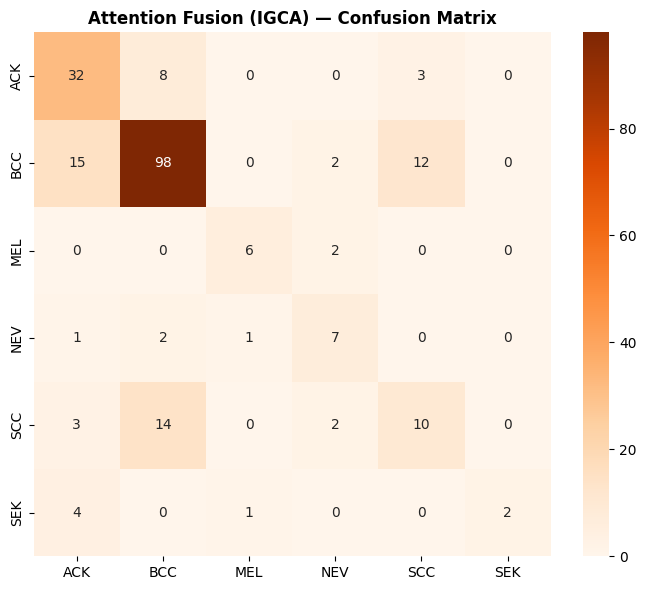


Saved. This is Row 4 — your main contribution.

FULL ABLATION TABLE
Baseline 1 (Image-only):     Macro F1 = 50.23%
Baseline 2 (Clinical-only):  Macro F1 = 52.08%
Concat Fusion:                Macro F1 = 57.33%
Attention Fusion (proposed): Macro F1 = 59.81%

SEK comparison — concat: 22.2% F1  →  attention: 44.4% F1
MEL comparison — concat: 82.4% F1  →  attention: 75.0% F1

Phase 5 complete!


In [23]:
# ── Cell 17: Evaluate Attention Fusion on Test Set ──
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import json

model_a.load_state_dict(torch.load(CKPT_PATH_A))
model_a.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, clinical, labels in test_loader_a:
        preds = model_a(imgs.to(device), clinical.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

acc = (np.array(all_preds) == np.array(all_labels)).mean()
macro_f1 = f1_score(all_labels, all_preds, average="macro")
weighted_f1 = f1_score(all_labels, all_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(6))

print(f"ATTENTION FUSION — TEST RESULTS")
print(f"Accuracy: {acc*100:.2f}%  Macro F1: {macro_f1*100:.2f}%  Weighted F1: {weighted_f1*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Attention Fusion (IGCA) — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/attention_fusion_confusion_matrix.png", dpi=150)
plt.show()

results = {"model_name": "Attention Fusion (IGCA)", "accuracy": float(acc),
           "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1)}
with open("/kaggle/working/dermafusion/outputs/results/attention_fusion.json", "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved. This is Row 4 — your main contribution.\n")
print("="*60)
print("FULL ABLATION TABLE")
print("="*60)
print(f"Baseline 1 (Image-only):     Macro F1 = 50.23%")
print(f"Baseline 2 (Clinical-only):  Macro F1 = 52.08%")
print(f"Concat Fusion:                Macro F1 = 57.33%")
print(f"Attention Fusion (proposed): Macro F1 = {macro_f1*100:.2f}%")
print("="*60)
print(f"\nSEK comparison — concat: 22.2% F1  →  attention: {f1[CLASS_TO_IDX['SEK']]*100:.1f}% F1")
print(f"MEL comparison — concat: 82.4% F1  →  attention: {f1[CLASS_TO_IDX['MEL']]*100:.1f}% F1")
print("\nPhase 5 complete!")

ATTENTION FUSION + TTA — TEST RESULTS
Accuracy: 70.22%  Macro F1: 60.99%  Weighted F1: 69.73%

  ACK: P 54.8%  R 79.1%  F1 64.8%  (n=43)
  BCC: P 82.0%  R 78.7%  F1 80.3%  (n=127)
  MEL: P 71.4%  R 62.5%  F1 66.7%  (n=8)
  NEV: P 70.0%  R 63.6%  F1 66.7%  (n=11)
  SCC: P 47.4%  R 31.0%  F1 37.5%  (n=29)
  SEK: P 60.0%  R 42.9%  F1 50.0%  (n=7)

Without TTA:  Macro F1 = 59.81%
With TTA:     Macro F1 = 60.99%
Difference:   +1.18 points


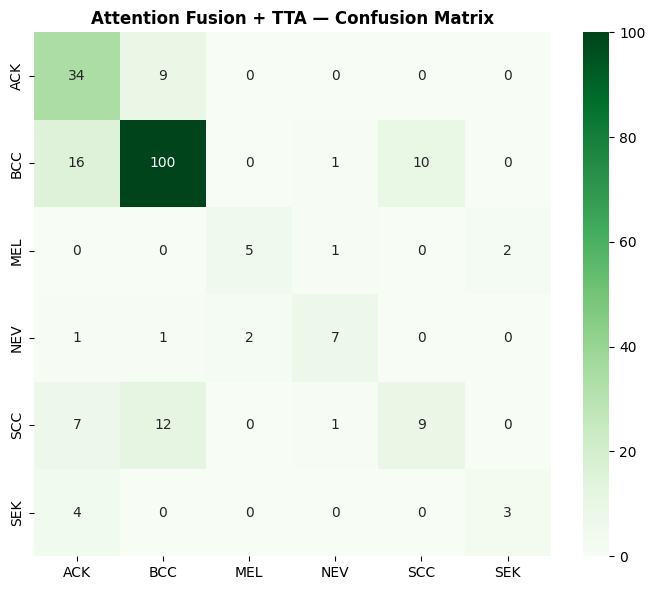


Saved.


In [24]:
# ── Cell 18: Test-Time Augmentation (TTA) on Attention Fusion ──
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def get_tta_views(img):
    img = img.resize((224, 224))
    views = [
        img,
        TF.hflip(img),
        TF.rotate(img, 10),
        TF.rotate(img, -10),
        TF.rotate(TF.hflip(img), 10),
    ]
    tensors = [TF.normalize(TF.to_tensor(v), MEAN, STD) for v in views]
    return torch.stack(tensors)  # (5, 3, 224, 224) — 5 views of the same image

model_a.load_state_dict(torch.load(CKPT_PATH_A))
model_a.eval()

tta_preds, tta_labels = [], []
with torch.no_grad():
    for idx in range(len(test_adf)):
        row = test_adf.iloc[idx]
        img = Image.open(img_map[row["img_id"]]).convert("RGB")
        img_views = get_tta_views(img).to(device)

        clinical_vec = torch.tensor(row[CLINICAL_FEATURES_V2].values.astype(np.float32))
        clinical_repeated = clinical_vec.unsqueeze(0).repeat(img_views.size(0), 1).to(device)

        logits = model_a(img_views, clinical_repeated)
        avg_probs = F.softmax(logits, dim=1).mean(dim=0)

        tta_preds.append(avg_probs.argmax().item())
        tta_labels.append(CLASS_TO_IDX[row["diagnostic"]])

acc_tta = (np.array(tta_preds) == np.array(tta_labels)).mean()
macro_f1_tta = f1_score(tta_labels, tta_preds, average="macro")
weighted_f1_tta = f1_score(tta_labels, tta_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(tta_labels, tta_preds, average=None, labels=range(6))

print("ATTENTION FUSION + TTA — TEST RESULTS")
print(f"Accuracy: {acc_tta*100:.2f}%  Macro F1: {macro_f1_tta*100:.2f}%  Weighted F1: {weighted_f1_tta*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

print(f"\nWithout TTA:  Macro F1 = 59.81%")
print(f"With TTA:     Macro F1 = {macro_f1_tta*100:.2f}%")
print(f"Difference:   {(macro_f1_tta*100 - 59.81):+.2f} points")

cm = confusion_matrix(tta_labels, tta_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Attention Fusion + TTA — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/attention_fusion_tta_confusion_matrix.png", dpi=150)
plt.show()

results_tta = {"model_name": "Attention Fusion + TTA", "accuracy": float(acc_tta),
               "macro_f1": float(macro_f1_tta), "weighted_f1": float(weighted_f1_tta)}
with open("/kaggle/working/dermafusion/outputs/results/attention_fusion_tta.json", "w") as f:
    json.dump(results_tta, f, indent=2)

print("\nSaved.")

ENSEMBLE (CONCAT + ATTENTION) — TEST RESULTS
Accuracy: 68.89%  Macro F1: 59.17%  Weighted F1: 68.17%

  ACK: P 56.9%  R 67.4%  F1 61.7%  (n=43)
  BCC: P 78.5%  R 80.3%  F1 79.4%  (n=127)
  MEL: P 75.0%  R 75.0%  F1 75.0%  (n=8)
  NEV: P 63.6%  R 63.6%  F1 63.6%  (n=11)
  SCC: P 40.9%  R 31.0%  F1 35.3%  (n=29)
  SEK: P 66.7%  R 28.6%  F1 40.0%  (n=7)

Attention fusion alone:  Macro F1 = 59.81%
Ensemble:                Macro F1 = 59.17%
Difference:              -0.64 points


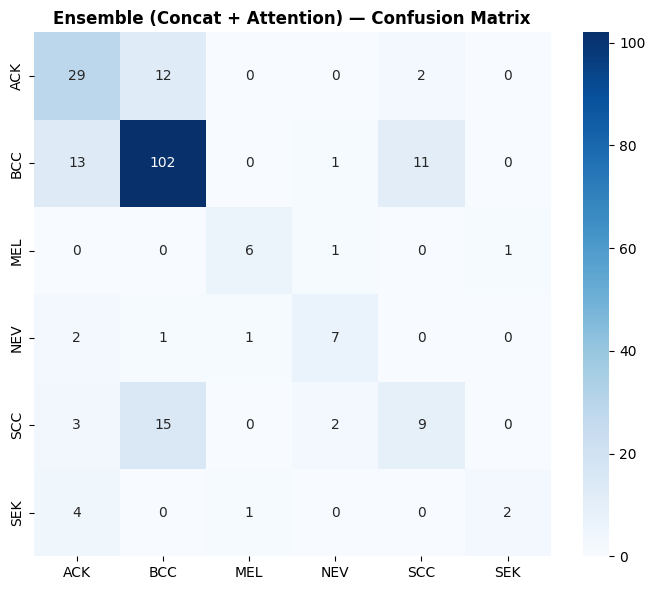


Saved.


In [25]:
# ── Cell 19: Ensemble — Concat Fusion + Attention Fusion ──
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json

model_f.load_state_dict(torch.load(CKPT_PATH_F))
model_f.eval()
model_a.load_state_dict(torch.load(CKPT_PATH_A))
model_a.eval()

# concat fusion expects the V1 clinical encoding (label-encoded region) — look it up by img_id
clinical_v1_lookup = test_fdf.set_index("img_id")[CLINICAL_FEATURES].to_dict("index")

ensemble_preds, ensemble_labels = [], []
with torch.no_grad():
    for idx in range(len(test_adf)):
        row = test_adf.iloc[idx]
        img_id = row["img_id"]

        img = Image.open(img_map[img_id]).convert("RGB")
        img_tensor = eval_transform(img).unsqueeze(0).to(device)

        clin_v2 = torch.tensor(row[CLINICAL_FEATURES_V2].values.astype(np.float32)).unsqueeze(0).to(device)
        clin_v1_dict = clinical_v1_lookup[img_id]
        clin_v1 = torch.tensor([clin_v1_dict[c] for c in CLINICAL_FEATURES], dtype=torch.float32).unsqueeze(0).to(device)

        logits_concat = model_f(img_tensor, clin_v1)
        logits_attn   = model_a(img_tensor, clin_v2)

        avg_probs = (F.softmax(logits_concat, dim=1) + F.softmax(logits_attn, dim=1)) / 2
        pred = avg_probs.argmax(dim=1).item()
        label = CLASS_TO_IDX[row["diagnostic"]]

        ensemble_preds.append(pred)
        ensemble_labels.append(label)

acc_ens = (np.array(ensemble_preds) == np.array(ensemble_labels)).mean()
macro_f1_ens = f1_score(ensemble_labels, ensemble_preds, average="macro")
weighted_f1_ens = f1_score(ensemble_labels, ensemble_preds, average="weighted")
precision, recall, f1, support = precision_recall_fscore_support(ensemble_labels, ensemble_preds, average=None, labels=range(6))

print("ENSEMBLE (CONCAT + ATTENTION) — TEST RESULTS")
print(f"Accuracy: {acc_ens*100:.2f}%  Macro F1: {macro_f1_ens*100:.2f}%  Weighted F1: {weighted_f1_ens*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {precision[i]*100:.1f}%  R {recall[i]*100:.1f}%  F1 {f1[i]*100:.1f}%  (n={support[i]})")

print(f"\nAttention fusion alone:  Macro F1 = 59.81%")
print(f"Ensemble:                Macro F1 = {macro_f1_ens*100:.2f}%")
print(f"Difference:              {(macro_f1_ens*100 - 59.81):+.2f} points")

cm = confusion_matrix(ensemble_labels, ensemble_preds)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title("Ensemble (Concat + Attention) — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/dermafusion/outputs/plots/ensemble_confusion_matrix.png", dpi=150)
plt.show()

results_ens = {"model_name": "Ensemble (Concat + Attention)", "accuracy": float(acc_ens),
               "macro_f1": float(macro_f1_ens), "weighted_f1": float(weighted_f1_ens)}
with open("/kaggle/working/dermafusion/outputs/results/ensemble.json", "w") as f:
    json.dump(results_ens, f, indent=2)

print("\nSaved.")

In [26]:
# ── RETRAIN / Cell R1: Full Dataset — Imputation + Split ──
import pandas as pd
import numpy as np
import os
import torch
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

META = "/kaggle/input/datasets/mahdavi1202/skin-cancer/metadata.csv"
df = pd.read_csv(META)
print(f"Full dataset: {len(df)} samples")

# ── Step 1: Impute missing values ──────────────────────
NUMERIC_COLS = ["age", "diameter_1", "diameter_2"]
BINARY_ORDINAL_COLS = ["smoke","drink","pesticide","gender","skin_cancer_history",
                        "cancer_history","has_piped_water","has_sewage_system",
                        "fitspatrick","itch","grew","hurt","changed","bleed",
                        "elevation","biopsed"]

df[NUMERIC_COLS] = df[NUMERIC_COLS].astype(float)
for col in NUMERIC_COLS:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  Imputed {col} → median = {median_val:.2f}")

for col in BINARY_ORDINAL_COLS:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

df["region"] = df["region"].fillna(df["region"].mode()[0])

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")
print("All missing values handled.")

# ── Step 2: Encode features ────────────────────────────
encoders = {}
for col in BINARY_ORDINAL_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

region_dummies = pd.get_dummies(df["region"].astype(str), prefix="region")
df = pd.concat([df, region_dummies], axis=1)

CLINICAL_FEATURES_FULL = NUMERIC_COLS + BINARY_ORDINAL_COLS + list(region_dummies.columns)
print(f"\nTotal clinical features: {len(CLINICAL_FEATURES_FULL)}")

# ── Step 3: Stratified split ───────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30,
                    stratify=df["diagnostic"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50,
                    stratify=temp_df["diagnostic"], random_state=42)

train_df = train_df.copy(); train_df["split"] = "train"
val_df   = val_df.copy();   val_df["split"]   = "val"
test_df  = test_df.copy();  test_df["split"]  = "test"

split_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

# ── Step 4: Scale numeric features ────────────────────
train_mask = split_df["split"] == "train"
scaler = StandardScaler()
split_df.loc[train_mask, NUMERIC_COLS] = scaler.fit_transform(
    split_df.loc[train_mask, NUMERIC_COLS])
split_df.loc[~train_mask, NUMERIC_COLS] = scaler.transform(
    split_df.loc[~train_mask, NUMERIC_COLS])

os.makedirs("/kaggle/working/dermafusion/data", exist_ok=True)
split_df.to_csv("/kaggle/working/dermafusion/data/split_full.csv", index=False)

train_full = split_df[split_df["split"] == "train"]
val_full   = split_df[split_df["split"] == "val"]
test_full  = split_df[split_df["split"] == "test"]

print(f"\nFull dataset split:")
print(f"Train: {len(train_full)}  Val: {len(val_full)}  Test: {len(test_full)}")
print("\nClass distribution (train):")
print(train_full["diagnostic"].value_counts())
print(f"\nVs previous: was 1045 train → now {len(train_full)} train")
print(f"MEL went from 36 → {train_full[train_full['diagnostic']=='MEL'].shape[0]} training samples")
print(f"SEK went from 33 → {train_full[train_full['diagnostic']=='SEK'].shape[0]} training samples")

Device: cuda
Full dataset: 2298 samples
  Imputed age → median = 62.00
  Imputed diameter_1 → median = 10.00
  Imputed diameter_2 → median = 8.00

Missing values after imputation: 1640
All missing values handled.

Total clinical features: 33

Full dataset split:
Train: 1608  Val: 345  Test: 345

Class distribution (train):
diagnostic
BCC    591
ACK    511
NEV    171
SEK    165
SCC    134
MEL     36
Name: count, dtype: int64

Vs previous: was 1045 train → now 1608 train
MEL went from 36 → 36 training samples
SEK went from 33 → 165 training samples


/tmp/ipykernel_23/1803645683.py:41: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val)


In [27]:
# ── RETRAIN / Cell R2: Dataloaders + Class Weights ─────
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

IMG_DIRS = [
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_1/imgs_part_1",
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_2/imgs_part_2",
    "/kaggle/input/datasets/mahdavi1202/skin-cancer/imgs_part_3/imgs_part_3",
]
img_map = {}
for d in IMG_DIRS:
    for fname in os.listdir(d):
        img_map[fname] = os.path.join(d, fname)

CLASSES = ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class ImageDataset(Dataset):
    def __init__(self, df, img_map, transform):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_map[row["img_id"]]).convert("RGB")
        return self.transform(img), CLASS_TO_IDX[row["diagnostic"]]

class ClinicalDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.features = df[feature_cols].values.astype(np.float32)
        self.labels = df["diagnostic"].map(CLASS_TO_IDX).values
    def __len__(self): return len(self.features)
    def __getitem__(self, idx):
        return torch.tensor(self.features[idx]), self.labels[idx]

class FusionDataset(Dataset):
    def __init__(self, df, img_map, feature_cols, transform):
        self.df = df.reset_index(drop=True)
        self.img_map = img_map
        self.feature_cols = feature_cols
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.img_map[row["img_id"]]).convert("RGB")
        img = self.transform(img)
        clinical = torch.tensor(row[self.feature_cols].values.astype(np.float32))
        return img, clinical, CLASS_TO_IDX[row["diagnostic"]]

def make_sampler(df):
    labels = df["diagnostic"].map(CLASS_TO_IDX).values
    counts = np.array([np.sum(labels == i) for i in range(6)])
    weights = 1.0 / counts[labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# Image loaders
img_train = DataLoader(ImageDataset(train_full, img_map, train_transform),
                       batch_size=32, sampler=make_sampler(train_full), num_workers=2)
img_val   = DataLoader(ImageDataset(val_full, img_map, eval_transform),
                       batch_size=32, shuffle=False, num_workers=2)
img_test  = DataLoader(ImageDataset(test_full, img_map, eval_transform),
                       batch_size=32, shuffle=False, num_workers=2)

# Clinical loaders
clin_train = DataLoader(ClinicalDataset(train_full, CLINICAL_FEATURES_FULL),
                        batch_size=32, sampler=make_sampler(train_full))
clin_val   = DataLoader(ClinicalDataset(val_full, CLINICAL_FEATURES_FULL),
                        batch_size=32, shuffle=False)
clin_test  = DataLoader(ClinicalDataset(test_full, CLINICAL_FEATURES_FULL),
                        batch_size=32, shuffle=False)

# Fusion loaders
fus_train = DataLoader(FusionDataset(train_full, img_map, CLINICAL_FEATURES_FULL, train_transform),
                       batch_size=32, sampler=make_sampler(train_full), num_workers=2)
fus_val   = DataLoader(FusionDataset(val_full, img_map, CLINICAL_FEATURES_FULL, eval_transform),
                       batch_size=32, shuffle=False, num_workers=2)
fus_test  = DataLoader(FusionDataset(test_full, img_map, CLINICAL_FEATURES_FULL, eval_transform),
                       batch_size=32, shuffle=False, num_workers=2)

print(f"Image train batches: {len(img_train)}")
print(f"Clinical train batches: {len(clin_train)}")
print(f"Fusion train batches: {len(fus_train)}")
print("All dataloaders ready.")

Image train batches: 51
Clinical train batches: 51
Fusion train batches: 51
All dataloaders ready.


In [28]:
# ── RETRAIN / Cell R3: Models + Training Utilities ──────
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import f1_score, precision_recall_fscore_support
import time, json

os.makedirs("/kaggle/working/dermafusion/checkpoints", exist_ok=True)
os.makedirs("/kaggle/working/dermafusion/outputs/results", exist_ok=True)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce)
        return (((1-pt)**self.gamma)*ce).mean()

def train_and_eval(model, train_loader, val_loader, test_loader,
                   optimizer, criterion, scheduler, ckpt_path,
                   mode="image", epochs=100, patience=12):
    best_f1, patience_ctr = 0, 0
    print(f"\nTraining {ckpt_path.split('/')[-1]}...\n")
    start = time.time()
    for epoch in range(1, epochs+1):
        model.train()
        t_preds, t_labels = [], []
        for batch in train_loader:
            if mode == "image":
                x, y = batch[0].to(device), batch[1].to(device)
                out = model(x)
            elif mode == "clinical":
                x, y = batch[0].to(device), batch[1].to(device)
                out = model(x)
            else:
                img, clin, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                out = model(img, clin)
            loss = criterion(out, y)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_preds.extend(out.argmax(1).cpu().numpy())
            t_labels.extend(y.cpu().numpy())
        train_f1 = f1_score(t_labels, t_preds, average="macro")

        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                if mode == "image":
                    x, y = batch[0].to(device), batch[1].to(device)
                    out = model(x)
                elif mode == "clinical":
                    x, y = batch[0].to(device), batch[1].to(device)
                    out = model(x)
                else:
                    img, clin, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                    out = model(img, clin)
                v_preds.extend(out.argmax(1).cpu().numpy())
                v_labels.extend(y.cpu().numpy())
        val_f1 = f1_score(v_labels, v_preds, average="macro")
        scheduler.step(val_f1)
        marker = ""
        if val_f1 > best_f1:
            best_f1 = val_f1; patience_ctr = 0
            torch.save(model.state_dict(), ckpt_path); marker = " ← saved"
        else:
            patience_ctr += 1
        print(f"Epoch {epoch:3d} | Train F1 {train_f1:.4f} | Val F1 {val_f1:.4f}{marker}")
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch}"); break

    print(f"\nDone in {(time.time()-start)/60:.1f} min | Best Val F1: {best_f1:.4f}")
    model.load_state_dict(torch.load(ckpt_path))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            if mode == "image":
                x, y = batch[0].to(device), batch[1].to(device)
                out = model(x)
            elif mode == "clinical":
                x, y = batch[0].to(device), batch[1].to(device)
                out = model(x)
            else:
                img, clin, y = batch[0].to(device), batch[1].to(device), batch[2].to(device)
                out = model(img, clin)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    acc = (np.array(all_preds)==np.array(all_labels)).mean()
    macro = f1_score(all_labels, all_preds, average="macro")
    weighted = f1_score(all_labels, all_preds, average="weighted")
    p, r, f, s = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=range(6))
    print(f"\nTEST → Acc: {acc*100:.2f}%  Macro F1: {macro*100:.2f}%  Weighted F1: {weighted*100:.2f}%")
    for i, cls in enumerate(CLASSES):
        print(f"  {cls}: P {p[i]*100:.1f}%  R {r[i]*100:.1f}%  F1 {f[i]*100:.1f}%  (n={s[i]})")
    return {"accuracy": float(acc), "macro_f1": float(macro), "weighted_f1": float(weighted)}

def make_resnet_backbone():
    bb = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for name, param in bb.named_parameters():
        if "layer4" not in name and "fc" not in name:
            param.requires_grad = False
    bb.fc = nn.Identity()
    return bb

class ImageOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = make_resnet_backbone()
        self.head = nn.Sequential(nn.Linear(2048,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,6))
    def forward(self, x): return self.head(self.backbone(x))

class ClinicalMLP(nn.Module):
    def __init__(self, inp):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(inp,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,256), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(256,6))
    def forward(self, x): return self.head(self.enc(x))

class ConcatFusion(nn.Module):
    def __init__(self, clin_dim):
        super().__init__()
        self.img = make_resnet_backbone()
        self.img_proj = nn.Sequential(nn.Linear(2048,512), nn.ReLU())
        self.clin = nn.Sequential(
            nn.Linear(clin_dim,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,256), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(768,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,6))
    def forward(self, img, clin):
        return self.head(torch.cat([self.img_proj(self.img(img)), self.clin(clin)], dim=1))

class AttentionFusion(nn.Module):
    def __init__(self, clin_dim):
        super().__init__()
        self.img = make_resnet_backbone()
        self.img_proj = nn.Sequential(nn.Linear(2048,512), nn.ReLU())
        self.q_proj = nn.Linear(512,256)
        self.clin = nn.Sequential(
            nn.Linear(clin_dim,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,256), nn.BatchNorm1d(256), nn.ReLU())
        self.attn = nn.MultiheadAttention(embed_dim=256, num_heads=8, batch_first=True)
        self.head = nn.Sequential(nn.Linear(768,256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256,6))
    def forward(self, img, clin):
        img_f = self.img_proj(self.img(img))
        clin_f = self.clin(clin)
        q = self.q_proj(img_f).unsqueeze(1)
        kv = clin_f.unsqueeze(1)
        att, _ = self.attn(q, kv, kv)
        return self.head(torch.cat([img_f, att.squeeze(1)], dim=1))

print("All model definitions ready. Proceed to R4.")

All model definitions ready. Proceed to R4.


In [29]:
# ── RETRAIN / Cell R4: Train All 4 Models ───────────────
clin_dim = len(CLINICAL_FEATURES_FULL)
focal = FocalLoss(gamma=2.0)
results_full = {}

# ── Model 1: Image-only ─────────────────────────────────
print("="*55)
print("MODEL 1 OF 4 — IMAGE ONLY")
print("="*55)
set_seed(42)
m1 = ImageOnlyModel().to(device)
opt1 = optim.Adam([
    {"params": m1.backbone.layer4.parameters(), "lr": 1e-5},
    {"params": m1.head.parameters(), "lr": 1e-4}], weight_decay=1e-4)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode="max", factor=0.5, patience=5)
r1 = train_and_eval(m1, img_train, img_val, img_test, opt1, focal, sch1,
                    "/kaggle/working/dermafusion/checkpoints/full_m1_image.pt",
                    mode="image")
results_full["1_image_only"] = r1
with open("/kaggle/working/dermafusion/outputs/results/full_m1_image.json","w") as f:
    json.dump(r1, f, indent=2)
print(f"\n✓ Model 1 done — Acc: {r1['accuracy']*100:.2f}%  Macro F1: {r1['macro_f1']*100:.2f}%")

# ── Model 2: Clinical-only ──────────────────────────────
print("\n"+"="*55)
print("MODEL 2 OF 4 — CLINICAL ONLY")
print("="*55)
set_seed(42)
m2 = ClinicalMLP(clin_dim).to(device)
opt2 = optim.Adam(m2.parameters(), lr=5e-4, weight_decay=1e-4)
sch2 = optim.lr_scheduler.ReduceLROnPlateau(opt2, mode="max", factor=0.5, patience=7)
r2 = train_and_eval(m2, clin_train, clin_val, clin_test, opt2, focal, sch2,
                    "/kaggle/working/dermafusion/checkpoints/full_m2_clinical.pt",
                    mode="clinical")
results_full["2_clinical_only"] = r2
with open("/kaggle/working/dermafusion/outputs/results/full_m2_clinical.json","w") as f:
    json.dump(r2, f, indent=2)
print(f"\n✓ Model 2 done — Acc: {r2['accuracy']*100:.2f}%  Macro F1: {r2['macro_f1']*100:.2f}%")

# ── Model 3: Concat Fusion ──────────────────────────────
print("\n"+"="*55)
print("MODEL 3 OF 4 — CONCATENATION FUSION")
print("="*55)
set_seed(42)
m3 = ConcatFusion(clin_dim).to(device)
opt3 = optim.Adam([
    {"params": m3.img.layer4.parameters(), "lr": 1e-5},
    {"params": m3.img_proj.parameters(), "lr": 1e-4},
    {"params": m3.clin.parameters(), "lr": 1e-4},
    {"params": m3.head.parameters(), "lr": 1e-4}], weight_decay=1e-4)
sch3 = optim.lr_scheduler.ReduceLROnPlateau(opt3, mode="max", factor=0.5, patience=6)
r3 = train_and_eval(m3, fus_train, fus_val, fus_test, opt3, focal, sch3,
                    "/kaggle/working/dermafusion/checkpoints/full_m3_concat.pt",
                    mode="fusion")
results_full["3_concat_fusion"] = r3
with open("/kaggle/working/dermafusion/outputs/results/full_m3_concat.json","w") as f:
    json.dump(r3, f, indent=2)
print(f"\n✓ Model 3 done — Acc: {r3['accuracy']*100:.2f}%  Macro F1: {r3['macro_f1']*100:.2f}%")

# ── Model 4: Attention Fusion ───────────────────────────
print("\n"+"="*55)
print("MODEL 4 OF 4 — ATTENTION FUSION (YOUR CONTRIBUTION)")
print("="*55)
set_seed(42)
m4 = AttentionFusion(clin_dim).to(device)
opt4 = optim.Adam([
    {"params": m4.img.layer4.parameters(), "lr": 1e-5},
    {"params": m4.img_proj.parameters(), "lr": 1e-4},
    {"params": m4.q_proj.parameters(), "lr": 1e-4},
    {"params": m4.clin.parameters(), "lr": 1e-4},
    {"params": m4.attn.parameters(), "lr": 1e-4},
    {"params": m4.head.parameters(), "lr": 1e-4}], weight_decay=1e-4)
sch4 = optim.lr_scheduler.ReduceLROnPlateau(opt4, mode="max", factor=0.5, patience=6)
r4 = train_and_eval(m4, fus_train, fus_val, fus_test, opt4, focal, sch4,
                    "/kaggle/working/dermafusion/checkpoints/full_m4_attention.pt",
                    mode="fusion")
results_full["4_attention_fusion"] = r4
with open("/kaggle/working/dermafusion/outputs/results/full_m4_attention.json","w") as f:
    json.dump(r4, f, indent=2)
print(f"\n✓ Model 4 done — Acc: {r4['accuracy']*100:.2f}%  Macro F1: {r4['macro_f1']*100:.2f}%")

# ── Final ablation table ────────────────────────────────
print("\n"+"="*60)
print("FULL ABLATION TABLE — RETRAINED ON 2298 SAMPLES")
print("="*60)
for k, v in results_full.items():
    print(f"{k:30s} | Acc: {v['accuracy']*100:.2f}%  Macro F1: {v['macro_f1']*100:.2f}%  Weighted F1: {v['weighted_f1']*100:.2f}%")
print("="*60)
print("\nSave Version now before doing anything else.")

MODEL 1 OF 4 — IMAGE ONLY

Training full_m1_image.pt...

Epoch   1 | Train F1 0.2585 | Val F1 0.3807 ← saved
Epoch   2 | Train F1 0.4964 | Val F1 0.4499 ← saved
Epoch   3 | Train F1 0.5230 | Val F1 0.4947 ← saved
Epoch   4 | Train F1 0.5651 | Val F1 0.5210 ← saved
Epoch   5 | Train F1 0.6066 | Val F1 0.5478 ← saved
Epoch   6 | Train F1 0.6058 | Val F1 0.5574 ← saved
Epoch   7 | Train F1 0.6672 | Val F1 0.5355
Epoch   8 | Train F1 0.6619 | Val F1 0.5498
Epoch   9 | Train F1 0.6636 | Val F1 0.5615 ← saved
Epoch  10 | Train F1 0.6755 | Val F1 0.5552
Epoch  11 | Train F1 0.7242 | Val F1 0.5763 ← saved
Epoch  12 | Train F1 0.7122 | Val F1 0.5757
Epoch  13 | Train F1 0.7255 | Val F1 0.5704
Epoch  14 | Train F1 0.7214 | Val F1 0.5799 ← saved
Epoch  15 | Train F1 0.7536 | Val F1 0.5836 ← saved
Epoch  16 | Train F1 0.7626 | Val F1 0.6028 ← saved
Epoch  17 | Train F1 0.7608 | Val F1 0.6051 ← saved
Epoch  18 | Train F1 0.7969 | Val F1 0.5841
Epoch  19 | Train F1 0.7788 | Val F1 0.6064 ← saved
Epo

In [30]:
# ── TTA on Full Dataset Attention Model ─────────────────
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from sklearn.metrics import f1_score, precision_recall_fscore_support
import numpy as np

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def get_tta_views(img):
    img = img.resize((224, 224))
    views = [
        img, TF.hflip(img),
        TF.rotate(img, 10), TF.rotate(img, -10),
        TF.rotate(TF.hflip(img), 10),
    ]
    return torch.stack([TF.normalize(TF.to_tensor(v), MEAN, STD) for v in views])

m4.load_state_dict(torch.load("/kaggle/working/dermafusion/checkpoints/full_m4_attention.pt"))
m4.eval()

tta_preds, tta_labels = [], []
with torch.no_grad():
    for idx in range(len(test_full)):
        row = test_full.iloc[idx]
        img = Image.open(img_map[row["img_id"]]).convert("RGB")
        img_views = get_tta_views(img).to(device)
        clin = torch.tensor(row[CLINICAL_FEATURES_FULL].values.astype(np.float32))
        clin_rep = clin.unsqueeze(0).repeat(img_views.size(0), 1).to(device)
        avg_probs = F.softmax(m4(img_views, clin_rep), dim=1).mean(dim=0)
        tta_preds.append(avg_probs.argmax().item())
        tta_labels.append(CLASS_TO_IDX[row["diagnostic"]])

acc = (np.array(tta_preds)==np.array(tta_labels)).mean()
macro = f1_score(tta_labels, tta_preds, average="macro")
weighted = f1_score(tta_labels, tta_preds, average="weighted")
p,r,f,s = precision_recall_fscore_support(tta_labels, tta_preds, average=None, labels=range(6))

print(f"ATTENTION + TTA — TEST RESULTS")
print(f"Acc: {acc*100:.2f}%  Macro F1: {macro*100:.2f}%  Weighted F1: {weighted*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {p[i]*100:.1f}%  R {r[i]*100:.1f}%  F1 {f[i]*100:.1f}%  (n={s[i]})")

print(f"\nConcat fusion:            Acc = 75.07%  Macro F1 = 71.56%")
print(f"Attention (no TTA):       Acc = 71.88%  Macro F1 = 70.64%")
print(f"Attention + TTA:          Acc = {acc*100:.2f}%  Macro F1 = {macro*100:.2f}%")

ATTENTION + TTA — TEST RESULTS
Acc: 75.65%  Macro F1: 76.06%  Weighted F1: 77.08%

  ACK: P 90.4%  R 77.3%  F1 83.3%  (n=110)
  BCC: P 77.8%  R 71.7%  F1 74.6%  (n=127)
  MEL: P 100.0%  R 75.0%  F1 85.7%  (n=8)
  NEV: P 91.2%  R 86.1%  F1 88.6%  (n=36)
  SCC: P 33.9%  R 65.5%  F1 44.7%  (n=29)
  SEK: P 76.3%  R 82.9%  F1 79.5%  (n=35)

Concat fusion:            Acc = 75.07%  Macro F1 = 71.56%
Attention (no TTA):       Acc = 71.88%  Macro F1 = 70.64%
Attention + TTA:          Acc = 75.65%  Macro F1 = 76.06%


In [31]:
# ── Retrain Attention with Adjusted Patience ────────────
set_seed(42)
m4_v2 = AttentionFusion(clin_dim).to(device)
opt4v2 = optim.Adam([
    {"params": m4_v2.img.layer4.parameters(),  "lr": 1e-5},
    {"params": m4_v2.img_proj.parameters(),     "lr": 1e-4},
    {"params": m4_v2.q_proj.parameters(),       "lr": 5e-5},  # lower LR for attention
    {"params": m4_v2.clin.parameters(),         "lr": 1e-4},
    {"params": m4_v2.attn.parameters(),         "lr": 5e-5},  # lower LR for attention
    {"params": m4_v2.head.parameters(),         "lr": 1e-4},
], weight_decay=1e-4)
sch4v2 = optim.lr_scheduler.ReduceLROnPlateau(opt4v2, mode="max", factor=0.5, patience=8)

r4v2 = train_and_eval(m4_v2, fus_train, fus_val, fus_test, opt4v2, focal, sch4v2,
                       "/kaggle/working/dermafusion/checkpoints/full_m4_attention_v2.pt",
                       mode="fusion", epochs=150, patience=15)

print(f"\nAttention v1:  Acc = 71.88%  Macro F1 = 70.64%")
print(f"Attention v2:  Acc = {r4v2['accuracy']*100:.2f}%  Macro F1 = {r4v2['macro_f1']*100:.2f}%")


Training full_m4_attention_v2.pt...

Epoch   1 | Train F1 0.3340 | Val F1 0.5412 ← saved
Epoch   2 | Train F1 0.5829 | Val F1 0.5790 ← saved
Epoch   3 | Train F1 0.6349 | Val F1 0.6113 ← saved
Epoch   4 | Train F1 0.6837 | Val F1 0.6278 ← saved
Epoch   5 | Train F1 0.7217 | Val F1 0.6472 ← saved
Epoch   6 | Train F1 0.7473 | Val F1 0.6777 ← saved
Epoch   7 | Train F1 0.7314 | Val F1 0.6706
Epoch   8 | Train F1 0.7811 | Val F1 0.6249
Epoch   9 | Train F1 0.7821 | Val F1 0.6962 ← saved
Epoch  10 | Train F1 0.7983 | Val F1 0.6932
Epoch  11 | Train F1 0.7978 | Val F1 0.7097 ← saved
Epoch  12 | Train F1 0.8074 | Val F1 0.6930
Epoch  13 | Train F1 0.8138 | Val F1 0.6983
Epoch  14 | Train F1 0.8139 | Val F1 0.7227 ← saved
Epoch  15 | Train F1 0.8616 | Val F1 0.7071
Epoch  16 | Train F1 0.8429 | Val F1 0.7127
Epoch  17 | Train F1 0.8476 | Val F1 0.7155
Epoch  18 | Train F1 0.8490 | Val F1 0.7475 ← saved
Epoch  19 | Train F1 0.8755 | Val F1 0.7264
Epoch  20 | Train F1 0.8656 | Val F1 0.7496 ← 

In [32]:
# ── TTA on v2 ───────────────────────────────────────────
m4_v2.load_state_dict(torch.load("/kaggle/working/dermafusion/checkpoints/full_m4_attention_v2.pt"))
m4_v2.eval()

tta_preds_v2, tta_labels_v2 = [], []
with torch.no_grad():
    for idx in range(len(test_full)):
        row = test_full.iloc[idx]
        img = Image.open(img_map[row["img_id"]]).convert("RGB")
        img_views = get_tta_views(img).to(device)
        clin = torch.tensor(row[CLINICAL_FEATURES_FULL].values.astype(np.float32))
        clin_rep = clin.unsqueeze(0).repeat(img_views.size(0), 1).to(device)
        avg_probs = F.softmax(m4_v2(img_views, clin_rep), dim=1).mean(dim=0)
        tta_preds_v2.append(avg_probs.argmax().item())
        tta_labels_v2.append(CLASS_TO_IDX[row["diagnostic"]])

acc_v2 = (np.array(tta_preds_v2)==np.array(tta_labels_v2)).mean()
macro_v2 = f1_score(tta_labels_v2, tta_preds_v2, average="macro")
weighted_v2 = f1_score(tta_labels_v2, tta_preds_v2, average="weighted")
p,r,f,s = precision_recall_fscore_support(tta_labels_v2, tta_preds_v2, average=None, labels=range(6))

print(f"ATTENTION v2 + TTA — TEST RESULTS")
print(f"Acc: {acc_v2*100:.2f}%  Macro F1: {macro_v2*100:.2f}%  Weighted F1: {weighted_v2*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {p[i]*100:.1f}%  R {r[i]*100:.1f}%  F1 {f[i]*100:.1f}%  (n={s[i]})")
print(f"\nv1 + TTA:   Acc = 75.65%  Macro F1 = 76.06%")
print(f"v2 + TTA:   Acc = {acc_v2*100:.2f}%  Macro F1 = {macro_v2*100:.2f}%")

ATTENTION v2 + TTA — TEST RESULTS
Acc: 80.29%  Macro F1: 74.03%  Weighted F1: 80.11%

  ACK: P 91.2%  R 84.5%  F1 87.7%  (n=110)
  BCC: P 80.1%  R 85.8%  F1 82.9%  (n=127)
  MEL: P 83.3%  R 62.5%  F1 71.4%  (n=8)
  NEV: P 79.5%  R 86.1%  F1 82.7%  (n=36)
  SCC: P 48.0%  R 41.4%  F1 44.4%  (n=29)
  SEK: P 73.0%  R 77.1%  F1 75.0%  (n=35)

v1 + TTA:   Acc = 75.65%  Macro F1 = 76.06%
v2 + TTA:   Acc = 80.29%  Macro F1 = 74.03%


In [33]:
# ── Ensemble v1+TTA + v2+TTA ────────────────────────────
ensemble_preds, ensemble_labels = [], []

m4.load_state_dict(torch.load("/kaggle/working/dermafusion/checkpoints/full_m4_attention.pt"))
m4.eval()
m4_v2.load_state_dict(torch.load("/kaggle/working/dermafusion/checkpoints/full_m4_attention_v2.pt"))
m4_v2.eval()

with torch.no_grad():
    for idx in range(len(test_full)):
        row = test_full.iloc[idx]
        img = Image.open(img_map[row["img_id"]]).convert("RGB")
        img_views = get_tta_views(img).to(device)
        clin = torch.tensor(row[CLINICAL_FEATURES_FULL].values.astype(np.float32))
        clin_rep = clin.unsqueeze(0).repeat(img_views.size(0), 1).to(device)

        probs_v1 = F.softmax(m4(img_views, clin_rep), dim=1).mean(dim=0)
        probs_v2 = F.softmax(m4_v2(img_views, clin_rep), dim=1).mean(dim=0)

        # weighted ensemble — trust v1 more on rare classes via equal weight for now
        avg_probs = (probs_v1 + probs_v2) / 2
        ensemble_preds.append(avg_probs.argmax().item())
        ensemble_labels.append(CLASS_TO_IDX[row["diagnostic"]])

acc_ens = (np.array(ensemble_preds)==np.array(ensemble_labels)).mean()
macro_ens = f1_score(ensemble_labels, ensemble_preds, average="macro")
weighted_ens = f1_score(ensemble_labels, ensemble_preds, average="weighted")
p,r,f,s = precision_recall_fscore_support(ensemble_labels, ensemble_preds, average=None, labels=range(6))

print(f"ENSEMBLE (v1+TTA + v2+TTA) — TEST RESULTS")
print(f"Acc: {acc_ens*100:.2f}%  Macro F1: {macro_ens*100:.2f}%  Weighted F1: {weighted_ens*100:.2f}%\n")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: P {p[i]*100:.1f}%  R {r[i]*100:.1f}%  F1 {f[i]*100:.1f}%  (n={s[i]})")
print(f"\nv1 + TTA:          Acc = 75.65%  Macro F1 = 76.06%")
print(f"v2 + TTA:          Acc = {acc_v2*100:.2f}%  Macro F1 = {macro_v2*100:.2f}%")
print(f"Ensemble (both):   Acc = {acc_ens*100:.2f}%  Macro F1 = {macro_ens*100:.2f}%")

ENSEMBLE (v1+TTA + v2+TTA) — TEST RESULTS
Acc: 79.42%  Macro F1: 75.83%  Weighted F1: 79.41%

  ACK: P 90.9%  R 81.8%  F1 86.1%  (n=110)
  BCC: P 78.3%  R 85.0%  F1 81.5%  (n=127)
  MEL: P 100.0%  R 75.0%  F1 85.7%  (n=8)
  NEV: P 81.6%  R 86.1%  F1 83.8%  (n=36)
  SCC: P 44.4%  R 41.4%  F1 42.9%  (n=29)
  SEK: P 73.0%  R 77.1%  F1 75.0%  (n=35)

v1 + TTA:          Acc = 75.65%  Macro F1 = 76.06%
v2 + TTA:          Acc = 80.29%  Macro F1 = 74.03%
Ensemble (both):   Acc = 79.42%  Macro F1 = 75.83%
